In [10]:
!pip -q install xgboost catboost joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


In [11]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import shutil
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier

from catboost import CatBoostClassifier


print("✅ ALL LIBRARIES READY")

✅ ALL LIBRARIES READY


In [16]:
# ============================================================
# CELL 3 — UPLOAD DATASET
# ============================================================

from google.colab import files

print("Upload DataCoSupplyChainDataset.csv")

uploaded = files.upload()

uploaded_name = list(uploaded.keys())[0]

DATA_PATH = "/content/" + uploaded_name


df = pd.read_csv(
    DATA_PATH,
    encoding="latin1",
    low_memory=False
)


print("\n✅ DATASET LOADED")

print(
    "Dataset shape:",
    df.shape
)

display(
    df.head()
)

Upload DataCoSupplyChainDataset.csv


Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset.csv

✅ DATASET LOADED
Dataset shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [17]:
# ============================================================
# CELL 4 — DATASET INSPECTION
# ============================================================

print("======================================")
print("DATASET INFORMATION")
print("======================================")

print("\nRows:", df.shape[0])

print(
    "Columns:",
    df.shape[1]
)


print("\nColumn Names:\n")

for number, column in enumerate(
    df.columns,
    1
):

    print(
        number,
        column
    )


print("\nTop Missing Values:")

missing_values = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

display(
    missing_values.head(20)
)

DATASET INFORMATION

Rows: 180519
Columns: 53

Column Names:

1 Type
2 Days for shipping (real)
3 Days for shipment (scheduled)
4 Benefit per order
5 Sales per customer
6 Delivery Status
7 Late_delivery_risk
8 Category Id
9 Category Name
10 Customer City
11 Customer Country
12 Customer Email
13 Customer Fname
14 Customer Id
15 Customer Lname
16 Customer Password
17 Customer Segment
18 Customer State
19 Customer Street
20 Customer Zipcode
21 Department Id
22 Department Name
23 Latitude
24 Longitude
25 Market
26 Order City
27 Order Country
28 Order Customer Id
29 order date (DateOrders)
30 Order Id
31 Order Item Cardprod Id
32 Order Item Discount
33 Order Item Discount Rate
34 Order Item Id
35 Order Item Product Price
36 Order Item Profit Ratio
37 Order Item Quantity
38 Sales
39 Order Item Total
40 Order Profit Per Order
41 Order Region
42 Order State
43 Order Status
44 Order Zipcode
45 Product Card Id
46 Product Category Id
47 Product Description
48 Product Image
49 Product Name
50 Prod

,0
Product Description,180519
Order Zipcode,155679
Customer Lname,8
Customer Zipcode,3
Days for shipment (scheduled),0
Sales per customer,0
Benefit per order,0
Delivery Status,0
Late_delivery_risk,0
Customer City,0


In [18]:
# ============================================================
# CELL 5 — TARGET + DATE PROCESSING
# ============================================================

TARGET_COL = "Order Profit Per Order"

DATE_COL = "order date (DateOrders)"


# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------

required_columns = [
    TARGET_COL,
    DATE_COL
]

missing_required = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_required:

    raise ValueError(
        f"❌ Missing required columns: {missing_required}"
    )


# ------------------------------------------------------------
# Profit → numeric
# ------------------------------------------------------------

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)


# ------------------------------------------------------------
# Date conversion
# ------------------------------------------------------------

df["Order_Date"] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ------------------------------------------------------------
# Remove unusable records
# ------------------------------------------------------------

df = df.dropna(
    subset=[
        TARGET_COL,
        "Order_Date"
    ]
).copy()


# ------------------------------------------------------------
# Target
# ------------------------------------------------------------

df["Profitable"] = (
    df[TARGET_COL] > 0
).astype("int8")


# ------------------------------------------------------------
# Date Features
# ------------------------------------------------------------

df["Order_Year"] = (
    df["Order_Date"].dt.year
)

df["Order_Month"] = (
    df["Order_Date"].dt.month
)

df["Order_DayOfWeek"] = (
    df["Order_Date"].dt.dayofweek
)

df["Order_Quarter"] = (
    df["Order_Date"].dt.quarter
)

df["Weekend"] = (
    df["Order_DayOfWeek"] >= 5
).astype("int8")


# ------------------------------------------------------------
# Chronological ordering
# ------------------------------------------------------------

df = df.sort_values(
    "Order_Date"
).reset_index(
    drop=True
)


print("✅ TARGET CREATED")


print("\nDataset Shape:")

print(
    df.shape
)


print("\nDate Range:")

print(
    df["Order_Date"].min(),
    "→",
    df["Order_Date"].max()
)


print("\nTarget Distribution:")

target_distribution = (
    df["Profitable"]
    .value_counts()
    .rename(
        index={
            0: "Non-Profitable",
            1: "Profitable"
        }
    )
)

display(
    target_distribution
)


print("\nTarget Percentage:")

display(
    (
        df["Profitable"]
        .value_counts(
            normalize=True
        )
        * 100
    ).round(2)
)

✅ TARGET CREATED

Dataset Shape:
(180519, 60)

Date Range:
2015-01-01 00:00:00 → 2018-01-31 23:38:00

Target Distribution:


,count
Profitable,
Profitable,145558
Non-Profitable,34961



Target Percentage:


,proportion
Profitable,
1,80.63
0,19.37


In [19]:
# ============================================================
# CELL 4 — DATASET INSPECTION
# ============================================================

print("======================================")
print("DATASET INFORMATION")
print("======================================")

print("\nRows:", df.shape[0])

print(
    "Columns:",
    df.shape[1]
)


print("\nColumn Names:\n")

for number, column in enumerate(
    df.columns,
    1
):

    print(
        number,
        column
    )


print("\nTop Missing Values:")

missing_values = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

display(
    missing_values.head(20)
)

DATASET INFORMATION

Rows: 180519
Columns: 60

Column Names:

1 Type
2 Days for shipping (real)
3 Days for shipment (scheduled)
4 Benefit per order
5 Sales per customer
6 Delivery Status
7 Late_delivery_risk
8 Category Id
9 Category Name
10 Customer City
11 Customer Country
12 Customer Email
13 Customer Fname
14 Customer Id
15 Customer Lname
16 Customer Password
17 Customer Segment
18 Customer State
19 Customer Street
20 Customer Zipcode
21 Department Id
22 Department Name
23 Latitude
24 Longitude
25 Market
26 Order City
27 Order Country
28 Order Customer Id
29 order date (DateOrders)
30 Order Id
31 Order Item Cardprod Id
32 Order Item Discount
33 Order Item Discount Rate
34 Order Item Id
35 Order Item Product Price
36 Order Item Profit Ratio
37 Order Item Quantity
38 Sales
39 Order Item Total
40 Order Profit Per Order
41 Order Region
42 Order State
43 Order Status
44 Order Zipcode
45 Product Card Id
46 Product Category Id
47 Product Description
48 Product Image
49 Product Name
50 Prod

,0
Product Description,180519
Order Zipcode,155679
Customer Lname,8
Customer Zipcode,3
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [21]:
# ============================================================
# CELL 5 — TARGET + DATE PROCESSING
# ============================================================

TARGET_COL = "Order Profit Per Order"

DATE_COL = "order date (DateOrders)"


# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------

required_columns = [
    TARGET_COL,
    DATE_COL
]

missing_required = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_required:

    raise ValueError(
        f"❌ Missing required columns: {missing_required}"
    )


# ------------------------------------------------------------
# Profit → numeric
# ------------------------------------------------------------

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)


# ------------------------------------------------------------
# Date conversion
# ------------------------------------------------------------

df["Order_Date"] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ------------------------------------------------------------
# Remove unusable records
# ------------------------------------------------------------

df = df.dropna(
    subset=[
        TARGET_COL,
        "Order_Date"
    ]
).copy()


# ------------------------------------------------------------
# Target
# ------------------------------------------------------------

df["Profitable"] = (
    df[TARGET_COL] > 0
).astype("int8")


# ------------------------------------------------------------
# Date Features
# ------------------------------------------------------------

df["Order_Year"] = (
    df["Order_Date"].dt.year
)

df["Order_Month"] = (
    df["Order_Date"].dt.month
)

df["Order_DayOfWeek"] = (
    df["Order_Date"].dt.dayofweek
)

df["Order_Quarter"] = (
    df["Order_Date"].dt.quarter
)

df["Weekend"] = (
    df["Order_DayOfWeek"] >= 5
).astype("int8")


# ------------------------------------------------------------
# Chronological ordering
# ------------------------------------------------------------

df = df.sort_values(
    "Order_Date"
).reset_index(
    drop=True
)


print("✅ TARGET CREATED")


print("\nDataset Shape:")

print(
    df.shape
)


print("\nDate Range:")

print(
    df["Order_Date"].min(),
    "→",
    df["Order_Date"].max()
)


print("\nTarget Distribution:")

target_distribution = (
    df["Profitable"]
    .value_counts()
    .rename(
        index={
            0: "Non-Profitable",
            1: "Profitable"
        }
    )
)

display(
    target_distribution
)


print("\nTarget Percentage:")

display(
    (
        df["Profitable"]
        .value_counts(
            normalize=True
        )
        * 100
    ).round(2)
)

✅ TARGET CREATED

Dataset Shape:
(180519, 60)

Date Range:
2015-01-01 00:00:00 → 2018-01-31 23:38:00

Target Distribution:


,count
Profitable,
Profitable,145558
Non-Profitable,34961



Target Percentage:


,proportion
Profitable,
1,80.63
0,19.37


In [22]:
# ============================================================
# CELL 6 — LEAKAGE-SAFE FEATURES
# ============================================================

NUMERIC_FEATURES = [

    "Days for shipment (scheduled)",

    "Category Id",

    "Department Id",

    "Order Item Discount",

    "Order Item Discount Rate",

    "Order Item Quantity",

    "Order Item Product Price",

    "Product Category Id",

    "Product Price",

    "Product Status",

    "Order_Year",

    "Order_Month",

    "Order_Quarter",

    "Order_DayOfWeek",

    "Weekend"
]


CATEGORICAL_FEATURES = [

    "Type",

    "Category Name",

    "Customer Segment",

    "Department Name",

    "Market",

    "Order Country",

    "Order Region",

    "Shipping Mode"
]


FEATURES = (
    NUMERIC_FEATURES
    +
    CATEGORICAL_FEATURES
)


missing_features = [

    col

    for col in FEATURES

    if col not in df.columns
]


if missing_features:

    raise ValueError(

        f"❌ Missing Features: {missing_features}"

    )


print("✅ FEATURE VALIDATION PASSED")

print(
    "\nTotal Features:",
    len(FEATURES)
)


print("\nNumeric Features:")

print(
    NUMERIC_FEATURES
)


print("\nCategorical Features:")

print(
    CATEGORICAL_FEATURES
)

✅ FEATURE VALIDATION PASSED

Total Features: 23

Numeric Features:
['Days for shipment (scheduled)', 'Category Id', 'Department Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Quantity', 'Order Item Product Price', 'Product Category Id', 'Product Price', 'Product Status', 'Order_Year', 'Order_Month', 'Order_Quarter', 'Order_DayOfWeek', 'Weekend']

Categorical Features:
['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Market', 'Order Country', 'Order Region', 'Shipping Mode']


In [23]:
# ============================================================
# CELL 7 — LEAKAGE AUDIT
# ============================================================

LEAKAGE_COLUMNS = [

    "Order Profit Per Order",

    "Order Item Profit Ratio",

    "Benefit per order",

    "Sales",

    "Sales per customer",

    "Order Item Total",

    "Days for shipping (real)",

    "Delivery Status",

    "Late_delivery_risk",

    "shipping date (DateOrders)",

    "Order Status",

    "Customer Email",

    "Customer Password",

    "Customer Fname",

    "Customer Lname",

    "Customer Street",

    "Customer Zipcode",

    "Customer Id",

    "Order Customer Id"
]


used_leakage_columns = [

    col

    for col in LEAKAGE_COLUMNS

    if col in FEATURES
]


print("======================================")
print("LEAKAGE AUDIT")
print("======================================")


if len(
    used_leakage_columns
) == 0:

    print(
        "✅ LEAKAGE AUDIT PASSED"
    )

    print(
        "No forbidden columns used."
    )

else:

    print(
        "❌ LEAKAGE DETECTED"
    )

    print(
        used_leakage_columns
    )


assert TARGET_COL not in FEATURES

LEAKAGE AUDIT
✅ LEAKAGE AUDIT PASSED
No forbidden columns used.


In [24]:
# ============================================================
# CELL 8 — CHRONOLOGICAL SPLIT
# ============================================================

total_rows = len(
    df
)


train_end = int(
    total_rows * 0.70
)


validation_end = int(
    total_rows * 0.85
)


train_df = df.iloc[
    :train_end
].copy()


validation_df = df.iloc[
    train_end:validation_end
].copy()


test_df = df.iloc[
    validation_end:
].copy()


# ------------------------------------------------------------
# Normal ML datasets
# ------------------------------------------------------------

X_train = train_df[
    FEATURES
].copy()

y_train = train_df[
    "Profitable"
].copy()


X_validation = validation_df[
    FEATURES
].copy()

y_validation = validation_df[
    "Profitable"
].copy()


X_test = test_df[
    FEATURES
].copy()

y_test = test_df[
    "Profitable"
].copy()


print("======================================")
print("CHRONOLOGICAL SPLIT")
print("======================================")


print("\nTRAIN")

print(
    "Rows:",
    len(train_df)
)

print(
    train_df["Order_Date"].min(),
    "→",
    train_df["Order_Date"].max()
)


print("\nVALIDATION")

print(
    "Rows:",
    len(validation_df)
)

print(
    validation_df["Order_Date"].min(),
    "→",
    validation_df["Order_Date"].max()
)


print("\nTEST")

print(
    "Rows:",
    len(test_df)
)

print(
    test_df["Order_Date"].min(),
    "→",
    test_df["Order_Date"].max()
)

CHRONOLOGICAL SPLIT

TRAIN
Rows: 126363
2015-01-01 00:00:00 → 2017-01-08 02:49:00

VALIDATION
Rows: 27078
2017-01-08 02:49:00 → 2017-06-14 07:19:00

TEST
Rows: 27078
2017-06-14 07:19:00 → 2018-01-31 23:38:00


In [25]:
# ============================================================
# CELL 9 — CATBOOST DATA PREPARATION
# ============================================================

def prepare_catboost_data(data):

    data = data.copy()

    # Numeric columns
    for col in NUMERIC_FEATURES:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )

    # Categorical columns
    for col in CATEGORICAL_FEATURES:

        data[col] = (
            data[col]
            .fillna("__MISSING__")
            .astype(str)
        )

    return data


X_train_cat = prepare_catboost_data(
    X_train
)

X_validation_cat = prepare_catboost_data(
    X_validation
)

X_test_cat = prepare_catboost_data(
    X_test
)


print("✅ CATBOOST DATA READY")

✅ CATBOOST DATA READY


In [26]:
# ============================================================
# CELL 10 — PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([

    (

        "imputer",

        SimpleImputer(
            strategy="median"
        )

    )

])


categorical_pipeline = Pipeline([

    (

        "imputer",

        SimpleImputer(
            strategy="most_frequent"
        )

    ),

    (

        "onehot",

        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=5
        )

    )

])


preprocessor = ColumnTransformer([

    (

        "numeric",

        numeric_pipeline,

        NUMERIC_FEATURES

    ),

    (

        "categorical",

        categorical_pipeline,

        CATEGORICAL_FEATURES

    )

])


print(
    "✅ PREPROCESSING PIPELINE READY"
)

✅ PREPROCESSING PIPELINE READY


In [27]:
# ============================================================
# CELL 11 — TRAIN FOUR MODELS
# ============================================================

models = {}


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

models[
    "Logistic Regression"
] = Pipeline([

    (

        "preprocessor",

        preprocessor

    ),

    (

        "model",

        LogisticRegression(

            max_iter=1500,

            class_weight="balanced",

            solver="liblinear",

            random_state=42

        )

    )

])


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

models[
    "Random Forest"
] = Pipeline([

    (

        "preprocessor",

        preprocessor

    ),

    (

        "model",

        RandomForestClassifier(

            n_estimators=300,

            max_depth=15,

            min_samples_leaf=5,

            class_weight="balanced",

            n_jobs=-1,

            random_state=42

        )

    )

])


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

models[
    "XGBoost"
] = Pipeline([

    (

        "preprocessor",

        preprocessor

    ),

    (

        "model",

        XGBClassifier(

            n_estimators=300,

            max_depth=5,

            learning_rate=0.05,

            subsample=0.8,

            colsample_bytree=0.8,

            eval_metric="logloss",

            tree_method="hist",

            n_jobs=-1,

            random_state=42

        )

    )

])


# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

catboost_model = CatBoostClassifier(

    iterations=500,

    depth=7,

    learning_rate=0.05,

    loss_function="Logloss",

    eval_metric="AUC",

    cat_features=CATEGORICAL_FEATURES,

    verbose=0,

    random_seed=42,

    thread_count=-1

)


print(
    "✅ FOUR MODELS CREATED"
)

✅ FOUR MODELS CREATED


In [28]:
# ============================================================
# BASELINE TRAINING
# ============================================================

baseline_results = []

model_registry = {}


# ------------------------------------------------------------
# Logistic / RF / XGBoost
# ------------------------------------------------------------

for name, model in models.items():

    print(
        "\nTraining:",
        name
    )


    model.fit(
        X_train,
        y_train
    )


    probability = model.predict_proba(
        X_validation
    )[:, 1]


    prediction = (
        probability >= 0.50
    ).astype(int)


    baseline_results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_validation,
                prediction
            ),

        "Precision":
            precision_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_validation,
                probability
            ),

        "PR_AUC":
            average_precision_score(
                y_validation,
                probability
            )

    })


    model_registry[
        name
    ] = {

        "model": model,

        "type": "pipeline"

    }


# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

print(
    "\nTraining: CatBoost"
)


catboost_model.fit(

    X_train_cat,

    y_train

)


cat_probability = (
    catboost_model
    .predict_proba(
        X_validation_cat
    )[:, 1]
)


cat_prediction = (
    cat_probability >= 0.50
).astype(int)


baseline_results.append({

    "Model":
        "CatBoost",

    "Accuracy":
        accuracy_score(
            y_validation,
            cat_prediction
        ),

    "Precision":
        precision_score(
            y_validation,
            cat_prediction,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_validation,
            cat_prediction,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_validation,
            cat_prediction,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_validation,
            cat_probability
        ),

    "PR_AUC":
        average_precision_score(
            y_validation,
            cat_probability
        )

})


model_registry[
    "CatBoost"
] = {

    "model":
        catboost_model,

    "type":
        "catboost"

}


baseline_comparison = (

    pd.DataFrame(
        baseline_results
    )

    .sort_values(
        "ROC_AUC",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


print("\n======================================")
print("BASELINE MODEL COMPARISON")
print("======================================")


display(
    baseline_comparison.round(4)
)


Training: Logistic Regression

Training: Random Forest

Training: XGBoost

Training: CatBoost

BASELINE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest,0.7653,0.8095,0.9279,0.8647,0.5095,0.8120
1,XGBoost,0.8083,0.8083,1.0000,0.8940,0.5052,0.8105
2,Logistic Regression,0.5825,0.8108,0.6306,0.7095,0.5041,0.8102
3,CatBoost,0.8083,0.8083,1.0000,0.8940,0.5025,0.8103


In [29]:
# ============================================================
# BASELINE TRAINING
# ============================================================

baseline_results = []

model_registry = {}


# ------------------------------------------------------------
# Logistic / RF / XGBoost
# ------------------------------------------------------------

for name, model in models.items():

    print(
        "\nTraining:",
        name
    )


    model.fit(
        X_train,
        y_train
    )


    probability = model.predict_proba(
        X_validation
    )[:, 1]


    prediction = (
        probability >= 0.50
    ).astype(int)


    baseline_results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_validation,
                prediction
            ),

        "Precision":
            precision_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_validation,
                probability
            ),

        "PR_AUC":
            average_precision_score(
                y_validation,
                probability
            )

    })


    model_registry[
        name
    ] = {

        "model": model,

        "type": "pipeline"

    }


# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

print(
    "\nTraining: CatBoost"
)


catboost_model.fit(

    X_train_cat,

    y_train

)


cat_probability = (
    catboost_model
    .predict_proba(
        X_validation_cat
    )[:, 1]
)


cat_prediction = (
    cat_probability >= 0.50
).astype(int)


baseline_results.append({

    "Model":
        "CatBoost",

    "Accuracy":
        accuracy_score(
            y_validation,
            cat_prediction
        ),

    "Precision":
        precision_score(
            y_validation,
            cat_prediction,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_validation,
            cat_prediction,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_validation,
            cat_prediction,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_validation,
            cat_probability
        ),

    "PR_AUC":
        average_precision_score(
            y_validation,
            cat_probability
        )

})


model_registry[
    "CatBoost"
] = {

    "model":
        catboost_model,

    "type":
        "catboost"

}


baseline_comparison = (

    pd.DataFrame(
        baseline_results
    )

    .sort_values(
        "ROC_AUC",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


print("\n======================================")
print("BASELINE MODEL COMPARISON")
print("======================================")


display(
    baseline_comparison.round(4)
)


Training: Logistic Regression

Training: Random Forest

Training: XGBoost

Training: CatBoost

BASELINE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest,0.7653,0.8095,0.9279,0.8647,0.5095,0.8120
1,XGBoost,0.8083,0.8083,1.0000,0.8940,0.5052,0.8105
2,Logistic Regression,0.5825,0.8108,0.6306,0.7095,0.5041,0.8102
3,CatBoost,0.8083,0.8083,1.0000,0.8940,0.5025,0.8103


In [30]:
# ============================================================
# CELL 12 — XGBOOST TUNING
# ============================================================

print(
    "Starting XGBoost tuning..."
)


xgb_tuning_pipeline = Pipeline([

    (

        "preprocessor",

        preprocessor

    ),

    (

        "model",

        XGBClassifier(

            objective="binary:logistic",

            eval_metric="logloss",

            tree_method="hist",

            n_jobs=-1,

            random_state=42

        )

    )

])


XGB_PARAMS = {

    "model__n_estimators": [
        200,
        300,
        400,
        500
    ],

    "model__max_depth": [
        3,
        5,
        7
    ],

    "model__learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10
    ],

    "model__subsample": [
        0.7,
        0.8,
        1.0
    ],

    "model__colsample_bytree": [
        0.7,
        0.8,
        1.0
    ],

    "model__min_child_weight": [
        1,
        3,
        5
    ]

}


xgb_search = RandomizedSearchCV(

    estimator=
        xgb_tuning_pipeline,

    param_distributions=
        XGB_PARAMS,

    n_iter=10,

    scoring="roc_auc",

    cv=TimeSeriesSplit(
        n_splits=3
    ),

    n_jobs=-1,

    random_state=42,

    verbose=1,

    refit=True

)


xgb_search.fit(

    X_train,

    y_train

)


best_xgb = (
    xgb_search
    .best_estimator_
)


print(
    "\n✅ XGBOOST TUNING COMPLETE"
)


print(
    "\nBest CV ROC-AUC:",
    round(
        xgb_search.best_score_,
        4
    )
)


print(
    "\nBest Parameters:"
)


print(
    xgb_search.best_params_
)

Starting XGBoost tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ XGBOOST TUNING COMPLETE

Best CV ROC-AUC: 0.5065

Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


In [34]:
# ============================================================
# STEP 13 — FAST CATBOOST TUNING
# ============================================================

from catboost import CatBoostClassifier
import pandas as pd
import numpy as np

print("🚀 Starting FAST CatBoost tuning...")

# ------------------------------------------------------------
# Strong but compact parameter candidates
# ------------------------------------------------------------

CATBOOST_CANDIDATES = [

    {
        "iterations": 350,
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 5
    },

    {
        "iterations": 450,
        "depth": 7,
        "learning_rate": 0.05,
        "l2_leaf_reg": 5
    },

    {
        "iterations": 350,
        "depth": 8,
        "learning_rate": 0.03,
        "l2_leaf_reg": 7
    },

    {
        "iterations": 300,
        "depth": 6,
        "learning_rate": 0.08,
        "l2_leaf_reg": 3
    }

]


cat_tuning_results = []

best_catboost = None
best_cat_auc = -1
best_cat_params = None


for i, params in enumerate(
    CATBOOST_CANDIDATES,
    start=1
):

    print(
        f"\nTraining CatBoost candidate "
        f"{i}/{len(CATBOOST_CANDIDATES)}"
    )

    model = CatBoostClassifier(

        **params,

        loss_function="Logloss",

        eval_metric="AUC",

        cat_features=CATEGORICAL_FEATURES,

        random_seed=42,

        verbose=False,

        allow_writing_files=False,

        thread_count=-1,

        # Faster on CPU
        bootstrap_type="Bernoulli",

        subsample=0.8

    )


    model.fit(

        X_train_cat,

        y_train,

        eval_set=(
            X_validation_cat,
            y_validation
        ),

        early_stopping_rounds=50,

        verbose=False

    )


    probability = model.predict_proba(
        X_validation_cat
    )[:, 1]


    auc = roc_auc_score(
        y_validation,
        probability
    )


    prediction = (
        probability >= 0.50
    ).astype(int)


    result = {

        "Candidate": i,

        "Iterations":
            model.get_best_iteration(),

        "Depth":
            params["depth"],

        "Learning_Rate":
            params["learning_rate"],

        "L2":
            params["l2_leaf_reg"],

        "Accuracy":
            accuracy_score(
                y_validation,
                prediction
            ),

        "Precision":
            precision_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "ROC_AUC":
            auc,

        "PR_AUC":
            average_precision_score(
                y_validation,
                probability
            )

    }


    cat_tuning_results.append(
        result
    )


    print(
        f"ROC-AUC: {auc:.4f}"
    )


    if auc > best_cat_auc:

        best_cat_auc = auc

        best_catboost = model

        best_cat_params = params.copy()


cat_tuning_df = (

    pd.DataFrame(
        cat_tuning_results
    )

    .sort_values(
        "ROC_AUC",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


print("\n======================================")
print("✅ FAST CATBOOST TUNING COMPLETE")
print("======================================")


print(
    "\nBest Validation ROC-AUC:",
    round(
        best_cat_auc,
        4
    )
)


print(
    "\nBest Parameters:"
)

print(
    best_cat_params
)


print(
    "\nBest actual iterations:",
    best_catboost.get_best_iteration()
)


display(
    cat_tuning_df.round(4)
)

🚀 Starting FAST CatBoost tuning...

Training CatBoost candidate 1/4
ROC-AUC: 0.5032

Training CatBoost candidate 2/4
ROC-AUC: 0.5092

Training CatBoost candidate 3/4
ROC-AUC: 0.5072

Training CatBoost candidate 4/4
ROC-AUC: 0.5084

✅ FAST CATBOOST TUNING COMPLETE

Best Validation ROC-AUC: 0.5092

Best Parameters:
{'iterations': 450, 'depth': 7, 'learning_rate': 0.05, 'l2_leaf_reg': 5}

Best actual iterations: 19


,Candidate,Iterations,Depth,Learning_Rate,L2,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,2,19,7,0.05,5,0.8083,0.8083,1.0,0.894,0.5092,0.8161
1,4,8,6,0.08,3,0.8083,0.8083,1.0,0.894,0.5084,0.8127
2,3,84,8,0.03,7,0.8083,0.8083,1.0,0.894,0.5072,0.8104
3,1,1,6,0.05,5,0.8083,0.8083,1.0,0.894,0.5032,0.8112


In [35]:
# ============================================================
# STEP 14 — TUNED MODEL COMPARISON
# ============================================================

print("Comparing tuned models...")


# ------------------------------------------------------------
# Tuned XGBoost
# ------------------------------------------------------------

xgb_val_probability = (
    best_xgb
    .predict_proba(
        X_validation
    )[:, 1]
)


xgb_val_prediction = (
    xgb_val_probability >= 0.50
).astype(int)


# ------------------------------------------------------------
# Tuned CatBoost
# ------------------------------------------------------------

cat_val_probability = (
    best_catboost
    .predict_proba(
        X_validation_cat
    )[:, 1]
)


cat_val_prediction = (
    cat_val_probability >= 0.50
).astype(int)


advanced_results = [

    {

        "Model":
            "Tuned XGBoost",

        "Accuracy":
            accuracy_score(
                y_validation,
                xgb_val_prediction
            ),

        "Precision":
            precision_score(
                y_validation,
                xgb_val_prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_validation,
                xgb_val_prediction,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_validation,
                xgb_val_prediction,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_validation,
                xgb_val_probability
            ),

        "PR_AUC":
            average_precision_score(
                y_validation,
                xgb_val_probability
            )

    },


    {

        "Model":
            "Tuned CatBoost",

        "Accuracy":
            accuracy_score(
                y_validation,
                cat_val_prediction
            ),

        "Precision":
            precision_score(
                y_validation,
                cat_val_prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_validation,
                cat_val_prediction,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_validation,
                cat_val_prediction,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_validation,
                cat_val_probability
            ),

        "PR_AUC":
            average_precision_score(
                y_validation,
                cat_val_probability
            )

    }

]


advanced_comparison = pd.DataFrame(
    advanced_results
)


final_validation_comparison = (

    pd.concat(

        [
            baseline_comparison,
            advanced_comparison
        ],

        ignore_index=True

    )

    .drop_duplicates(
        subset=["Model"],
        keep="last"
    )

    .sort_values(
        "ROC_AUC",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


print("\n======================================")
print("FINAL VALIDATION MODEL COMPARISON")
print("======================================")


display(
    final_validation_comparison.round(4)
)

Comparing tuned models...

FINAL VALIDATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned XGBoost,0.8080,0.8083,0.9995,0.8938,0.5117,0.8136
1,Random Forest,0.7653,0.8095,0.9279,0.8647,0.5095,0.8120
2,Tuned CatBoost,0.8083,0.8083,1.0000,0.8940,0.5092,0.8161
3,XGBoost,0.8083,0.8083,1.0000,0.8940,0.5052,0.8105
4,Logistic Regression,0.5825,0.8108,0.6306,0.7095,0.5041,0.8102
5,CatBoost,0.8083,0.8083,1.0000,0.8940,0.5025,0.8103


In [36]:
# ============================================================
# STEP 15 — SELECT WINNING MODEL
# ============================================================

model_registry[
    "Tuned XGBoost"
] = {

    "model":
        best_xgb,

    "type":
        "pipeline"

}


model_registry[
    "Tuned CatBoost"
] = {

    "model":
        best_catboost,

    "type":
        "catboost"

}


best_model_name = (

    final_validation_comparison
    .iloc[0]["Model"]

)


winner = model_registry[
    best_model_name
]


best_model = winner[
    "model"
]


best_model_type = winner[
    "type"
]


print("======================================")

print(
    "🏆 WINNING MODEL:",
    best_model_name
)

print(
    "Model Type:",
    best_model_type
)

print("======================================")

🏆 WINNING MODEL: Tuned XGBoost
Model Type: pipeline


In [37]:
# ============================================================
# STEP 16 — VALIDATION PROBABILITY
# ============================================================

if best_model_type == "catboost":

    validation_probability = (
        best_model
        .predict_proba(
            X_validation_cat
        )[:, 1]
    )

else:

    validation_probability = (
        best_model
        .predict_proba(
            X_validation
        )[:, 1]
    )


print(
    "✅ Validation probabilities ready"
)

✅ Validation probabilities ready


In [38]:
# ============================================================
# STEP 17 — THRESHOLD OPTIMIZATION
# ============================================================

threshold_values = np.arange(
    0.20,
    0.81,
    0.01
)


threshold_results = []


for threshold in threshold_values:

    prediction = (

        validation_probability
        >=
        threshold

    ).astype(int)


    threshold_results.append({

        "Threshold":
            round(
                float(threshold),
                2
            ),

        "Accuracy":
            accuracy_score(
                y_validation,
                prediction
            ),

        "Precision":
            precision_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_validation,
                prediction,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_validation,
                prediction,
                zero_division=0
            )

    })


threshold_df = pd.DataFrame(
    threshold_results
)


best_threshold = float(

    threshold_df.loc[

        threshold_df[
            "F1"
        ].idxmax(),

        "Threshold"

    ]

)


print(
    "✅ BEST THRESHOLD:",
    best_threshold
)


display(

    threshold_df
    .sort_values(
        "F1",
        ascending=False
    )
    .head(10)

)

✅ BEST THRESHOLD: 0.2


,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.808258,0.808258,1.0,0.893963
1,0.21,0.808258,0.808258,1.0,0.893963
2,0.22,0.808258,0.808258,1.0,0.893963
3,0.23,0.808258,0.808258,1.0,0.893963
4,0.24,0.808258,0.808258,1.0,0.893963
5,0.25,0.808258,0.808258,1.0,0.893963
6,0.26,0.808258,0.808258,1.0,0.893963
7,0.27,0.808258,0.808258,1.0,0.893963
8,0.28,0.808258,0.808258,1.0,0.893963
9,0.29,0.808258,0.808258,1.0,0.893963


In [39]:
# ============================================================
# STEP 18 — FINAL UNTOUCHED TEST
# ============================================================

if best_model_type == "catboost":

    test_probability = (

        best_model
        .predict_proba(
            X_test_cat
        )[:, 1]

    )

else:

    test_probability = (

        best_model
        .predict_proba(
            X_test
        )[:, 1]

    )


final_prediction = (

    test_probability
    >=
    best_threshold

).astype(int)


final_metrics = {

    "Accuracy":
        accuracy_score(
            y_test,
            final_prediction
        ),

    "Precision":
        precision_score(
            y_test,
            final_prediction,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_test,
            final_prediction,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_test,
            final_prediction,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_test,
            test_probability
        ),

    "PR_AUC":
        average_precision_score(
            y_test,
            test_probability
        )

}


print("======================================")
print("🏆 FINAL TEST RESULTS")
print("======================================")


print(
    "Winning Model:",
    best_model_name
)

print(
    "Threshold:",
    best_threshold
)


for metric, value in final_metrics.items():

    print(
        f"{metric}: {value:.4f}"
    )

🏆 FINAL TEST RESULTS
Winning Model: Tuned XGBoost
Threshold: 0.2
Accuracy: 0.8069
Precision: 0.8069
Recall: 1.0000
F1: 0.8931
ROC_AUC: 0.4978
PR_AUC: 0.8056


                precision    recall  f1-score   support

Non-Profitable       0.00      0.00      0.00      5229
    Profitable       0.81      1.00      0.89     21849

      accuracy                           0.81     27078
     macro avg       0.40      0.50      0.45     27078
  weighted avg       0.65      0.81      0.72     27078



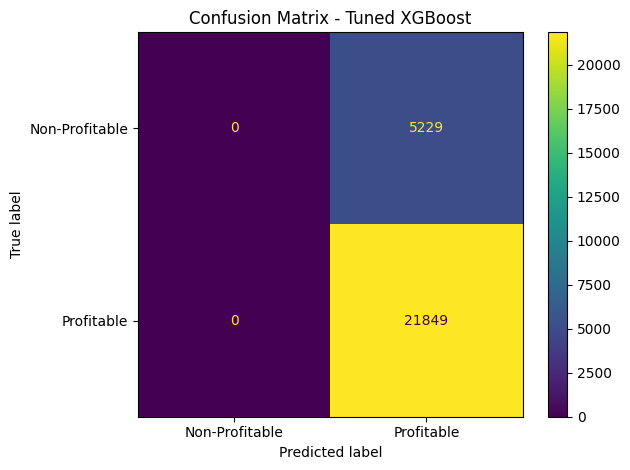

In [40]:
# ============================================================
# STEP 19 — CLASSIFICATION + CONFUSION MATRIX
# ============================================================

print(
    classification_report(

        y_test,

        final_prediction,

        target_names=[
            "Non-Profitable",
            "Profitable"
        ]

    )
)


ConfusionMatrixDisplay.from_predictions(

    y_test,

    final_prediction,

    display_labels=[
        "Non-Profitable",
        "Profitable"
    ]

)


plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.tight_layout()

plt.show()

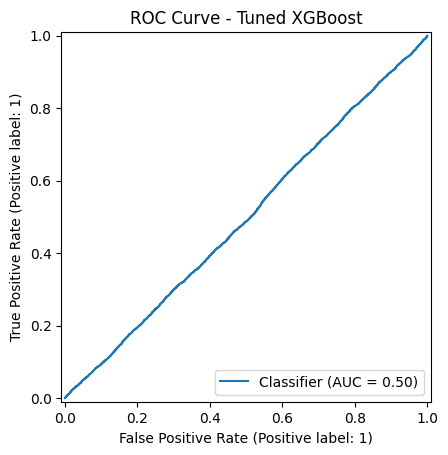

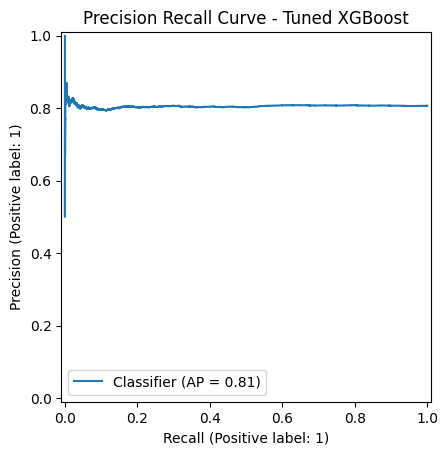

In [41]:
# ============================================================
# STEP 20 — ROC + PR CURVES
# ============================================================

RocCurveDisplay.from_predictions(

    y_test,

    test_probability

)

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.show()



PrecisionRecallDisplay.from_predictions(

    y_test,

    test_probability

)

plt.title(
    f"Precision Recall Curve - {best_model_name}"
)

plt.show()

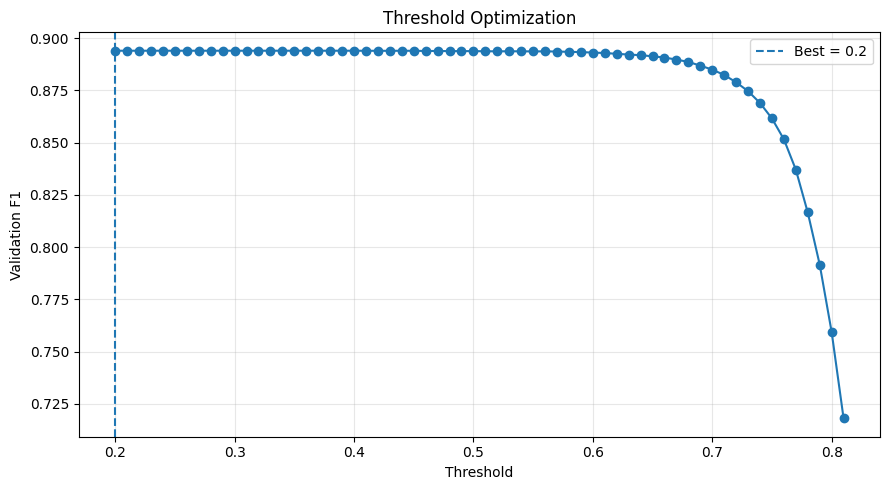

In [42]:
# ============================================================
# STEP 21 — THRESHOLD GRAPH
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(

    threshold_df[
        "Threshold"
    ],

    threshold_df[
        "F1"
    ],

    marker="o"

)


plt.axvline(

    best_threshold,

    linestyle="--",

    label=f"Best = {best_threshold}"

)


plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Validation F1"
)

plt.title(
    "Threshold Optimization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

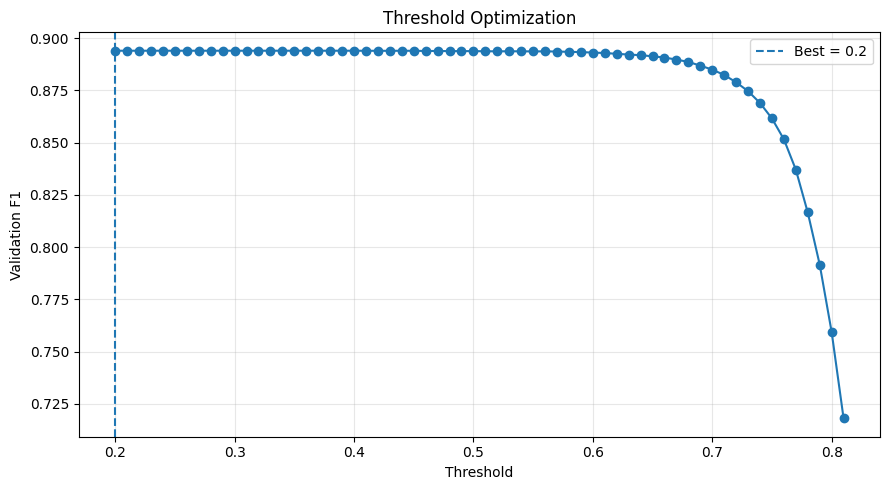

In [43]:
# ============================================================
# STEP 21 — THRESHOLD GRAPH
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(

    threshold_df[
        "Threshold"
    ],

    threshold_df[
        "F1"
    ],

    marker="o"

)


plt.axvline(

    best_threshold,

    linestyle="--",

    label=f"Best = {best_threshold}"

)


plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Validation F1"
)

plt.title(
    "Threshold Optimization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [44]:
# ============================================================
# STEP 22 — OVERFITTING CHECK
# ============================================================

if best_model_type == "catboost":

    train_probability = (

        best_model
        .predict_proba(
            X_train_cat
        )[:, 1]

    )

else:

    train_probability = (

        best_model
        .predict_proba(
            X_train
        )[:, 1]

    )


train_auc = roc_auc_score(

    y_train,

    train_probability

)


test_auc = roc_auc_score(

    y_test,

    test_probability

)


auc_gap = (
    train_auc
    -
    test_auc
)


print(
    f"Train ROC-AUC : {train_auc:.4f}"
)

print(
    f"Test ROC-AUC  : {test_auc:.4f}"
)

print(
    f"AUC Gap       : {auc_gap:.4f}"
)


if auc_gap < 0.05:

    overfit_status = (
        "Low apparent overfitting gap"
    )

elif auc_gap < 0.10:

    overfit_status = (
        "Moderate train-test gap"
    )

else:

    overfit_status = (
        "Large train-test gap"
    )


print(
    "\nAssessment:",
    overfit_status
)

Train ROC-AUC : 0.7538
Test ROC-AUC  : 0.4978
AUC Gap       : 0.2560

Assessment: Large train-test gap


TOP 20 FEATURES


,Feature,Importance
0,categorical__Order Region_South Asia,0.009371
1,categorical__Category Name_Men's Footwear,0.009027
2,categorical__Category Name_Cardio Equipment,0.008864
3,categorical__Category Name_Indoor/Outdoor Games,0.008733
4,categorical__Department Name_Golf,0.008637
5,categorical__Order Country_Turquía,0.008582
6,categorical__Order Region_US Center,0.008482
7,categorical__Order Region_Western Europe,0.008371
8,categorical__Category Name_Cleats,0.008280
9,categorical__Category Name_Women's Apparel,0.008254


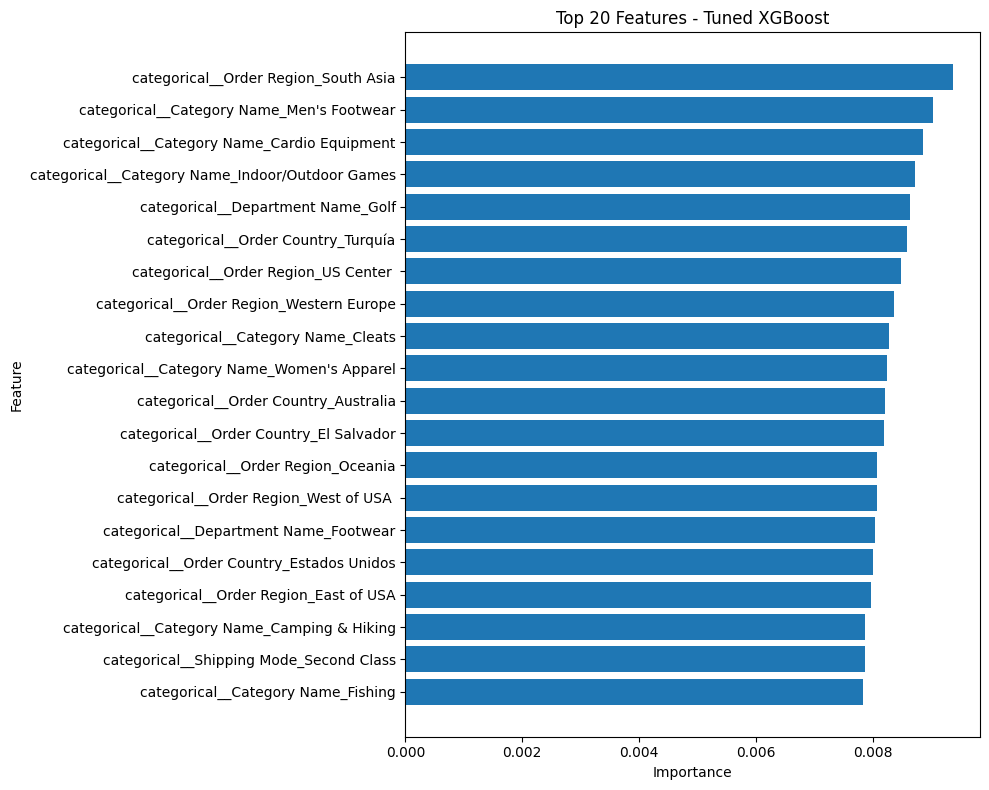

In [45]:
# ============================================================
# STEP 23 — FEATURE IMPORTANCE
# ============================================================

if best_model_type == "catboost":

    feature_names = FEATURES

    feature_importance = (
        best_model
        .get_feature_importance()
    )


else:

    fitted_preprocessor = (
        best_model
        .named_steps[
            "preprocessor"
        ]
    )


    fitted_estimator = (
        best_model
        .named_steps[
            "model"
        ]
    )


    feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )


    if hasattr(
        fitted_estimator,
        "feature_importances_"
    ):

        feature_importance = (
            fitted_estimator
            .feature_importances_
        )

    else:

        feature_importance = (
            np.abs(
                fitted_estimator
                .coef_[0]
            )
        )


importance_df = pd.DataFrame({

    "Feature":
        feature_names,

    "Importance":
        feature_importance

})


importance_df = (

    importance_df

    .sort_values(
        "Importance",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


print("TOP 20 FEATURES")

display(
    importance_df.head(20)
)


top20 = (

    importance_df
    .head(20)
    .sort_values(
        "Importance"
    )

)


plt.figure(
    figsize=(10, 8)
)


plt.barh(

    top20["Feature"],

    top20["Importance"]

)


plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    f"Top 20 Features - {best_model_name}"
)

plt.tight_layout()

plt.show()

In [46]:
# ============================================================
# STEP 24 — DRIFT + CALIBRATION CHECK
# ============================================================

# ------------------------------------------------------------
# DRIFT
# ------------------------------------------------------------

drift_rows = []


for col in NUMERIC_FEATURES:

    train_values = pd.to_numeric(
        X_train[col],
        errors="coerce"
    )


    test_values = pd.to_numeric(
        X_test[col],
        errors="coerce"
    )


    train_mean = train_values.mean()

    test_mean = test_values.mean()


    if (
        pd.notna(train_mean)
        and
        train_mean != 0
    ):

        relative_change = (

            abs(
                test_mean
                -
                train_mean
            )

            /

            abs(
                train_mean
            )

        )

    else:

        relative_change = np.nan


    drift_rows.append({

        "Feature":
            col,

        "Train_Mean":
            train_mean,

        "Test_Mean":
            test_mean,

        "Relative_Change":
            relative_change

    })


drift_df = (

    pd.DataFrame(
        drift_rows
    )

    .sort_values(
        "Relative_Change",
        ascending=False
    )

)


print("TRAIN / TEST DRIFT")

display(
    drift_df.round(4)
)



# ------------------------------------------------------------
# CALIBRATION
# ------------------------------------------------------------

calibration_df = pd.DataFrame({

    "Probability":
        test_probability,

    "Actual":
        y_test.values

})


calibration_df[
    "Probability_Band"
] = pd.cut(

    calibration_df[
        "Probability"
    ],

    bins=[
        0,
        0.2,
        0.4,
        0.6,
        0.8,
        1.0
    ],

    include_lowest=True

)


calibration_summary = (

    calibration_df

    .groupby(
        "Probability_Band",
        observed=False
    )

    .agg(

        Records=(
            "Actual",
            "count"
        ),

        Average_Predicted_Probability=(
            "Probability",
            "mean"
        ),

        Actual_Profitability=(
            "Actual",
            "mean"
        )

    )

    .reset_index()

)


print("\nPROBABILITY CALIBRATION")

display(
    calibration_summary.round(4)
)

TRAIN / TEST DRIFT


,Feature,Train_Mean,Test_Mean,Relative_Change
8,Product Price,131.2605,193.7698,0.4762
6,Order Item Product Price,131.2605,193.7698,0.4762
1,Category Id,30.0810,41.7304,0.3873
7,Product Category Id,30.0810,41.7304,0.3873
11,Order_Month,6.4848,7.9543,0.2266
3,Order Item Discount,19.9562,24.2159,0.2135
5,Order Item Quantity,2.2027,1.7391,0.2105
12,Order_Quarter,2.4992,2.9808,0.1927
2,Department Id,5.3412,5.9968,0.1228
0,Days for shipment (scheduled),2.9298,2.9210,0.0030



PROBABILITY CALIBRATION


,Probability_Band,Records,Average_Predicted_Probability,Actual_Profitability
0,"(-0.001, 0.2]",0,NaN,NaN
1,"(0.2, 0.4]",5,0.3693,1.0000
2,"(0.4, 0.6]",91,0.5590,0.8901
3,"(0.6, 0.8]",7532,0.7607,0.8034
4,"(0.8, 1.0]",19450,0.8467,0.8078


In [47]:
# ============================================================
# STEP 25 — FINAL BUSINESS DATASET
# ============================================================

scored = test_df[

    [

        "Order Id",

        "Market",

        "Order Region",

        "Order Country",

        "Category Name",

        "Department Name",

        "Customer Segment",

        "Shipping Mode",

        "Order Item Quantity",

        "Order Item Discount Rate",

        "Order Item Product Price",

        "Order_Date",

        "Order Profit Per Order",

        "Profitable"

    ]

].copy()


scored.rename(

    columns={

        "Profitable":
            "Actual_Profitable"

    },

    inplace=True

)


scored[
    "Profitability_Probability"
] = test_probability


scored[
    "Predicted_Profitable"
] = final_prediction


scored[
    "Correct_Prediction"
] = (

    scored[
        "Actual_Profitable"
    ]

    ==

    scored[
        "Predicted_Profitable"
    ]

).astype(int)


scored[
    "Profitability_Risk"
] = pd.cut(

    scored[
        "Profitability_Probability"
    ],

    bins=[
        -np.inf,
        0.40,
        0.70,
        np.inf
    ],

    labels=[
        "High Loss Risk",
        "Moderate Profitability",
        "High Profit Probability"
    ]

)


high_risk_orders = (

    scored[

        scored[
            "Profitability_Risk"
        ]

        ==

        "High Loss Risk"

    ]

    .sort_values(

        "Profitability_Probability",

        ascending=True

    )

)


print(
    "Total test orders:",
    len(scored)
)


print(
    "High loss risk orders:",
    len(high_risk_orders)
)


display(
    scored.head(10)
)

Total test orders: 27078
High loss risk orders: 5


,Order Id,Market,Order Region,Order Country,Category Name,Department Name,Customer Segment,Shipping Mode,Order Item Quantity,Order Item Discount Rate,Order Item Product Price,Order_Date,Order Profit Per Order,Actual_Profitable,Profitability_Probability,Predicted_Profitable,Correct_Prediction,Profitability_Risk
153441,61333,LATAM,South America,Brasil,Cardio Equipment,Footwear,Consumer,Standard Class,5,0.10,99.989998,2017-06-14 07:19:00,202.479996,1,0.788334,1,1,High Profit Probability
153442,61333,LATAM,South America,Brasil,Kids' Golf Clubs,Outdoors,Consumer,Standard Class,2,0.25,99.949997,2017-06-14 07:19:00,32.980000,1,0.830691,1,1,High Profit Probability
153443,61334,LATAM,South America,Brasil,Cleats,Apparel,Consumer,Standard Class,1,0.13,59.990002,2017-06-14 07:40:00,24.530001,1,0.776583,1,1,High Profit Probability
153444,61334,LATAM,South America,Brasil,Women's Apparel,Golf,Consumer,Standard Class,3,0.06,50.000000,2017-06-14 07:40:00,65.209999,1,0.778797,1,1,High Profit Probability
153445,61335,LATAM,South America,Brasil,Fishing,Fan Shop,Consumer,Standard Class,1,0.06,399.980011,2017-06-14 08:01:00,124.730003,1,0.861447,1,1,High Profit Probability
153446,61335,LATAM,South America,Brasil,Golf Gloves,Outdoors,Consumer,Standard Class,1,0.00,179.990005,2017-06-14 08:01:00,82.800003,1,0.846030,1,1,High Profit Probability
153447,61336,LATAM,South America,Brasil,Fishing,Fan Shop,Home Office,Standard Class,1,0.05,399.980011,2017-06-14 08:22:00,102.589996,1,0.884442,1,1,High Profit Probability
153448,61336,LATAM,South America,Brasil,Water Sports,Fan Shop,Home Office,Standard Class,1,0.06,199.990005,2017-06-14 08:22:00,85.050003,1,0.822733,1,1,High Profit Probability
153449,61336,LATAM,South America,Brasil,Shop By Sport,Golf,Home Office,Standard Class,1,0.07,39.990002,2017-06-14 08:22:00,17.850000,1,0.845606,1,1,High Profit Probability
153450,61336,LATAM,South America,Brasil,Cardio Equipment,Footwear,Home Office,Standard Class,1,0.17,99.989998,2017-06-14 08:22:00,39.009998,1,0.783526,1,1,High Profit Probability


In [48]:
# ============================================================
# STEP 26 — BUSINESS SUMMARIES
# ============================================================

market_summary = (

    scored

    .groupby(
        "Market"
    )

    .agg(

        Orders=(
            "Order Id",
            "count"
        ),

        Actual_Profitability=(
            "Actual_Profitable",
            "mean"
        ),

        Average_Profit=(
            "Order Profit Per Order",
            "mean"
        ),

        Average_Prediction=(
            "Profitability_Probability",
            "mean"
        )

    )

    .reset_index()

)


category_summary = (

    scored

    .groupby(
        "Category Name"
    )

    .agg(

        Orders=(
            "Order Id",
            "count"
        ),

        Actual_Profitability=(
            "Actual_Profitable",
            "mean"
        ),

        Average_Profit=(
            "Order Profit Per Order",
            "mean"
        ),

        Average_Prediction=(
            "Profitability_Probability",
            "mean"
        )

    )

    .reset_index()

)


shipping_summary = (

    scored

    .groupby(
        "Shipping Mode"
    )

    .agg(

        Orders=(
            "Order Id",
            "count"
        ),

        Actual_Profitability=(
            "Actual_Profitable",
            "mean"
        ),

        Average_Profit=(
            "Order Profit Per Order",
            "mean"
        )

    )

    .reset_index()

)


display(
    market_summary
)

display(
    category_summary.head(20)
)

display(
    shipping_summary
)

,Market,Orders,Actual_Profitability,Average_Profit,Average_Prediction
0,Europe,20903,0.807492,25.985797,0.825478
1,LATAM,555,0.800000,16.985027,0.833342
2,Pacific Asia,5620,0.805338,26.353927,0.806675


,Category Name,Orders,Actual_Profitability,Average_Profit,Average_Prediction
0,As Seen on TV!,43,0.837209,27.536977,0.828725
1,Baby,207,0.835749,7.367295,0.796794
2,Baseball & Softball,40,0.825000,24.249500,0.807039
3,Basketball,67,0.820896,27.547313,0.818283
4,Books,405,0.802469,2.180272,0.799157
5,Boxing & MMA,91,0.725275,5.843297,0.832934
6,CDs,271,0.856089,1.416421,0.816381
7,Cameras,592,0.817568,51.165203,0.832788
8,Camping & Hiking,1493,0.797053,28.610328,0.818473
9,Cardio Equipment,1354,0.800591,25.147998,0.828672


,Shipping Mode,Orders,Actual_Profitability,Average_Profit
0,First Class,4116,0.812439,28.482216
1,Same Day,1520,0.815789,24.878691
2,Second Class,5395,0.807970,24.451879
3,Standard Class,16047,0.804262,25.783671


In [49]:
# ============================================================
# STEP 27 — FINAL PROJECT SUMMARY
# ============================================================

summary_df = pd.DataFrame({

    "Property": [

        "Winning Model",

        "Best Threshold",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "ROC-AUC",

        "PR-AUC",

        "Train ROC-AUC",

        "Test ROC-AUC",

        "AUC Gap",

        "Training Rows",

        "Validation Rows",

        "Test Rows"

    ],


    "Value": [

        best_model_name,

        best_threshold,

        round(
            final_metrics["Accuracy"],
            4
        ),

        round(
            final_metrics["Precision"],
            4
        ),

        round(
            final_metrics["Recall"],
            4
        ),

        round(
            final_metrics["F1"],
            4
        ),

        round(
            final_metrics["ROC_AUC"],
            4
        ),

        round(
            final_metrics["PR_AUC"],
            4
        ),

        round(
            train_auc,
            4
        ),

        round(
            test_auc,
            4
        ),

        round(
            auc_gap,
            4
        ),

        len(
            train_df
        ),

        len(
            validation_df
        ),

        len(
            test_df
        )

    ]

})


display(
    summary_df
)

,Property,Value
0,Winning Model,Tuned XGBoost
1,Best Threshold,0.2
2,Accuracy,0.8069
3,Precision,0.8069
4,Recall,1.0
5,F1,0.8931
6,ROC-AUC,0.4978
7,PR-AUC,0.8056
8,Train ROC-AUC,0.7538
9,Test ROC-AUC,0.4978


In [50]:
# ============================================================
# STEP 28 — SAVE EVERYTHING
# ============================================================

from pathlib import Path
import joblib


OUTPUT_DIR = Path(

    "/content/DataCo_Profitability_Final"

)


OUTPUT_DIR.mkdir(

    exist_ok=True

)


# ------------------------------------------------------------
# CSV FILES
# ------------------------------------------------------------

scored.to_csv(

    OUTPUT_DIR /
    "DataCo_Final_Scored_Orders.csv",

    index=False

)


final_validation_comparison.to_csv(

    OUTPUT_DIR /
    "DataCo_Model_Comparison.csv",

    index=False

)


cat_tuning_df.to_csv(

    OUTPUT_DIR /
    "DataCo_CatBoost_Tuning.csv",

    index=False

)


threshold_df.to_csv(

    OUTPUT_DIR /
    "DataCo_Threshold_Analysis.csv",

    index=False

)


importance_df.to_csv(

    OUTPUT_DIR /
    "DataCo_Feature_Importance.csv",

    index=False

)


drift_df.to_csv(

    OUTPUT_DIR /
    "DataCo_Train_Test_Drift.csv",

    index=False

)


calibration_summary.to_csv(

    OUTPUT_DIR /
    "DataCo_Calibration_Check.csv",

    index=False

)


market_summary.to_csv(

    OUTPUT_DIR /
    "DataCo_Market_Summary.csv",

    index=False

)


category_summary.to_csv(

    OUTPUT_DIR /
    "DataCo_Category_Summary.csv",

    index=False

)


shipping_summary.to_csv(

    OUTPUT_DIR /
    "DataCo_Shipping_Summary.csv",

    index=False

)


high_risk_orders.to_csv(

    OUTPUT_DIR /
    "DataCo_High_Loss_Risk_Orders.csv",

    index=False

)


summary_df.to_csv(

    OUTPUT_DIR /
    "DataCo_Final_Project_Summary.csv",

    index=False

)


# ------------------------------------------------------------
# SAVE WINNER
# ------------------------------------------------------------

with open(

    OUTPUT_DIR /
    "Winning_Model.txt",

    "w"

) as file:

    file.write(
        str(
            best_model_name
        )
    )


with open(

    OUTPUT_DIR /
    "Best_Threshold.txt",

    "w"

) as file:

    file.write(
        str(
            best_threshold
        )
    )


# ------------------------------------------------------------
# Save model
# ------------------------------------------------------------

joblib.dump(

    best_model,

    OUTPUT_DIR /
    "DataCo_Final_Trained_Model.pkl"

)


# Extra CatBoost native file
if best_model_type == "catboost":

    best_model.save_model(

        str(

            OUTPUT_DIR /
            "DataCo_Final_CatBoost_Model.cbm"

        )

    )


print("======================================")

print(
    "✅ ALL PROJECT FILES SAVED"
)

print("======================================")


for file in sorted(
    OUTPUT_DIR.iterdir()
):

    print(
        "•",
        file.name
    )

✅ ALL PROJECT FILES SAVED
• Best_Threshold.txt
• DataCo_Calibration_Check.csv
• DataCo_CatBoost_Tuning.csv
• DataCo_Category_Summary.csv
• DataCo_Feature_Importance.csv
• DataCo_Final_Project_Summary.csv
• DataCo_Final_Scored_Orders.csv
• DataCo_Final_Trained_Model.pkl
• DataCo_High_Loss_Risk_Orders.csv
• DataCo_Market_Summary.csv
• DataCo_Model_Comparison.csv
• DataCo_Shipping_Summary.csv
• DataCo_Threshold_Analysis.csv
• DataCo_Train_Test_Drift.csv
• Winning_Model.txt


In [51]:
# ============================================================
# STEP 29 — FINAL ZIP DOWNLOAD
# ============================================================

import shutil

from google.colab import files


zip_path = shutil.make_archive(

    "/content/DataCo_Profitability_Final",

    "zip",

    OUTPUT_DIR

)


print(
    "✅ FINAL ZIP CREATED:"
)

print(
    zip_path
)


files.download(
    zip_path
)

✅ FINAL ZIP CREATED:
/content/DataCo_Profitability_Final.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
print("========================================")
print("FINAL PROJECT VERIFICATION")
print("========================================")

print("\n🏆 Winning Model:")
print(best_model_name)

print("\n🎯 Best Threshold:")
print(best_threshold)

print("\n📊 FINAL TEST METRICS:")

for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\n📦 Dataset Split:")
print("Training   :", len(train_df))
print("Validation :", len(validation_df))
print("Testing    :", len(test_df))

print("\n🔍 Overfitting Check:")
print(f"Train ROC-AUC : {train_auc:.4f}")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"Gap           : {auc_gap:.4f}")

print("\n📁 Final files:")

for file in sorted(OUTPUT_DIR.iterdir()):
    print("✓", file.name)

print("\n========================================")
print("✅ MACHINE LEARNING PIPELINE COMPLETE")
print("========================================")

FINAL PROJECT VERIFICATION

🏆 Winning Model:
Tuned XGBoost

🎯 Best Threshold:
0.2

📊 FINAL TEST METRICS:
Accuracy: 0.8069
Precision: 0.8069
Recall: 1.0000
F1: 0.8931
ROC_AUC: 0.4978
PR_AUC: 0.8056

📦 Dataset Split:
Training   : 126363
Validation : 27078
Testing    : 27078

🔍 Overfitting Check:
Train ROC-AUC : 0.7538
Test ROC-AUC  : 0.4978
Gap           : 0.2560

📁 Final files:
✓ Best_Threshold.txt
✓ DataCo_Calibration_Check.csv
✓ DataCo_CatBoost_Tuning.csv
✓ DataCo_Category_Summary.csv
✓ DataCo_Feature_Importance.csv
✓ DataCo_Final_Project_Summary.csv
✓ DataCo_Final_Scored_Orders.csv
✓ DataCo_Final_Trained_Model.pkl
✓ DataCo_High_Loss_Risk_Orders.csv
✓ DataCo_Market_Summary.csv
✓ DataCo_Model_Comparison.csv
✓ DataCo_Shipping_Summary.csv
✓ DataCo_Threshold_Analysis.csv
✓ DataCo_Train_Test_Drift.csv
✓ Winning_Model.txt

✅ MACHINE LEARNING PIPELINE COMPLETE


In [53]:
# ============================================================
# FINAL MODEL DIAGNOSTIC
# ============================================================

print("========================================")
print("TARGET DISTRIBUTION")
print("========================================")

print("\nTRAIN:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(4))

print("\nVALIDATION:")
print(y_validation.value_counts())
print(y_validation.value_counts(normalize=True).round(4))

print("\nTEST:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).round(4))


print("\n========================================")
print("FINAL PREDICTION DISTRIBUTION")
print("========================================")

pred_counts = pd.Series(
    final_prediction
).value_counts().sort_index()

print(pred_counts)

print("\nPrediction percentages:")

print(
    pd.Series(final_prediction)
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)


print("\n========================================")
print("PROBABILITY DISTRIBUTION")
print("========================================")

print(
    pd.Series(test_probability)
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)


print("\n========================================")
print("CONFUSION MATRIX")
print("========================================")

print(
    confusion_matrix(
        y_test,
        final_prediction
    )
)


print("\n========================================")
print("MODEL COMPARISON")
print("========================================")

display(
    final_validation_comparison.round(4)
)


print("\n========================================")
print("DATE DISTRIBUTION")
print("========================================")

print(
    "TRAIN:",
    train_df["Order_Date"].min(),
    "→",
    train_df["Order_Date"].max()
)

print(
    "VALIDATION:",
    validation_df["Order_Date"].min(),
    "→",
    validation_df["Order_Date"].max()
)

print(
    "TEST:",
    test_df["Order_Date"].min(),
    "→",
    test_df["Order_Date"].max()
)


print("\n========================================")
print("RESULT")
print("========================================")

print("Final Test ROC-AUC :", round(
    roc_auc_score(y_test, test_probability), 4
))

print("Final Test PR-AUC  :", round(
    average_precision_score(y_test, test_probability), 4
))

TARGET DISTRIBUTION

TRAIN:
Profitable
1    101823
0     24540
Name: count, dtype: int64
Profitable
1    0.8058
0    0.1942
Name: proportion, dtype: float64

VALIDATION:
Profitable
1    21886
0     5192
Name: count, dtype: int64
Profitable
1    0.8083
0    0.1917
Name: proportion, dtype: float64

TEST:
Profitable
1    21849
0     5229
Name: count, dtype: int64
Profitable
1    0.8069
0    0.1931
Name: proportion, dtype: float64

FINAL PREDICTION DISTRIBUTION
1    27078
Name: count, dtype: int64

Prediction percentages:
1    1.0
Name: proportion, dtype: float64

PROBABILITY DISTRIBUTION
count    27078.000000
mean         0.821736
std          0.052984
min          0.319046
1%           0.655889
5%           0.729174
10%          0.757175
25%          0.795194
50%          0.827089
75%          0.855903
90%          0.880950
95%          0.896214
99%          0.927419
max          0.973871
dtype: float64

CONFUSION MATRIX
[[    0  5229]
 [    0 21849]]

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned XGBoost,0.8080,0.8083,0.9995,0.8938,0.5117,0.8136
1,Random Forest,0.7653,0.8095,0.9279,0.8647,0.5095,0.8120
2,Tuned CatBoost,0.8083,0.8083,1.0000,0.8940,0.5092,0.8161
3,XGBoost,0.8083,0.8083,1.0000,0.8940,0.5052,0.8105
4,Logistic Regression,0.5825,0.8108,0.6306,0.7095,0.5041,0.8102
5,CatBoost,0.8083,0.8083,1.0000,0.8940,0.5025,0.8103



DATE DISTRIBUTION
TRAIN: 2015-01-01 00:00:00 → 2017-01-08 02:49:00
VALIDATION: 2017-01-08 02:49:00 → 2017-06-14 07:19:00
TEST: 2017-06-14 07:19:00 → 2018-01-31 23:38:00

RESULT
Final Test ROC-AUC : 0.4978
Final Test PR-AUC  : 0.8056


In [54]:
# ============================================================
# PROFITABILITY MODEL V2 — BETTER ORDER-TIME FEATURES
# ============================================================

NUMERIC_FEATURES_V2 = [

    "Days for shipment (scheduled)",

    "Category Id",
    "Department Id",

    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Quantity",
    "Order Item Product Price",

    "Product Category Id",
    "Product Price",
    "Product Status",

    # Commercial/order-time information
    "Sales",
    "Sales per customer",
    "Order Item Total",

    # Time information
    "Order_Year",
    "Order_Month",
    "Order_Quarter",
    "Order_DayOfWeek",
    "Weekend"
]


CATEGORICAL_FEATURES_V2 = [

    "Type",
    "Category Name",
    "Customer Segment",
    "Department Name",
    "Market",
    "Order Country",
    "Order Region",
    "Shipping Mode"
]


FEATURES_V2 = (
    NUMERIC_FEATURES_V2
    +
    CATEGORICAL_FEATURES_V2
)


missing_v2 = [
    c
    for c in FEATURES_V2
    if c not in df.columns
]


if missing_v2:

    print(
        "❌ Missing columns:",
        missing_v2
    )

else:

    print(
        "✅ V2 features ready"
    )

    print(
        "Total:",
        len(FEATURES_V2)
    )

✅ V2 features ready
Total: 26


In [55]:
DIRECT_LEAKAGE = [

    "Order Profit Per Order",
    "Benefit per order",
    "Order Item Profit Ratio",

    "Days for shipping (real)",
    "Delivery Status",
    "Late_delivery_risk",
    "Order Status",
    "shipping date (DateOrders)"
]


detected = [
    c
    for c in DIRECT_LEAKAGE
    if c in FEATURES_V2
]


print(
    "Leakage detected:",
    detected
)


assert len(detected) == 0


print(
    "✅ STRICT LEAKAGE AUDIT PASSED"
)

Leakage detected: []
✅ STRICT LEAKAGE AUDIT PASSED


In [56]:
# ============================================================
# CLEAN TEMPORAL SPLIT
# ============================================================

TRAIN_END = pd.Timestamp(
    "2017-01-01"
)

VALIDATION_END = pd.Timestamp(
    "2017-07-01"
)


train_v2 = df[
    df["Order_Date"] < TRAIN_END
].copy()


validation_v2 = df[
    (df["Order_Date"] >= TRAIN_END)
    &
    (df["Order_Date"] < VALIDATION_END)
].copy()


test_v2 = df[
    df["Order_Date"] >= VALIDATION_END
].copy()


X_train_v2 = train_v2[
    FEATURES_V2
]

y_train_v2 = train_v2[
    "Profitable"
]


X_validation_v2 = validation_v2[
    FEATURES_V2
]

y_validation_v2 = validation_v2[
    "Profitable"
]


X_test_v2 = test_v2[
    FEATURES_V2
]

y_test_v2 = test_v2[
    "Profitable"
]


print(
    "TRAIN:",
    X_train_v2.shape
)

print(
    "VALIDATION:",
    X_validation_v2.shape
)

print(
    "TEST:",
    X_test_v2.shape
)


print("\nTarget rates:")

print(
    "Train:",
    y_train_v2.mean()
)

print(
    "Validation:",
    y_validation_v2.mean()
)

print(
    "Test:",
    y_test_v2.mean()
)

TRAIN: (125200, 26)
VALIDATION: (30950, 26)
TEST: (24369, 26)

Target rates:
Train: 0.8056549520766774
Validation: 0.8072051696284329
Test: 0.8086913701834297


In [57]:
# ============================================================
# FINAL V3 — LOSS-RISK TARGET
# ============================================================

df["Loss_Risk"] = (
    df["Order Profit Per Order"] <= 0
).astype("int8")

print("======================================")
print("FINAL TARGET = LOSS RISK")
print("======================================")

print(df["Loss_Risk"].value_counts())

print("\nPercentages:")
print(
    (
        df["Loss_Risk"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

print("\n0 = Profitable")
print("1 = Non-Profitable / Loss Risk")

FINAL TARGET = LOSS RISK
Loss_Risk
0    145558
1     34961
Name: count, dtype: int64

Percentages:
Loss_Risk
0    80.63
1    19.37
Name: proportion, dtype: float64

0 = Profitable
1 = Non-Profitable / Loss Risk


In [58]:
# ============================================================
# FINAL V3 — FEATURES
# ============================================================

NUMERIC_V3 = [

    "Days for shipment (scheduled)",

    "Category Id",
    "Department Id",

    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Quantity",
    "Order Item Product Price",

    "Product Category Id",
    "Product Price",
    "Product Status",

    # Commercial information
    "Sales",
    "Sales per customer",
    "Order Item Total",

    # Time features
    "Order_Year",
    "Order_Month",
    "Order_Quarter",
    "Order_DayOfWeek",
    "Weekend"
]


CATEGORICAL_V3 = [

    "Type",
    "Category Name",
    "Customer Segment",
    "Department Name",
    "Market",
    "Order Country",
    "Order Region",
    "Shipping Mode"
]


FEATURES_V3 = (
    NUMERIC_V3
    +
    CATEGORICAL_V3
)


missing = [
    c
    for c in FEATURES_V3
    if c not in df.columns
]


if missing:
    raise ValueError(
        f"Missing columns: {missing}"
    )


print("✅ FINAL V3 FEATURES READY")
print("Total features:", len(FEATURES_V3))

✅ FINAL V3 FEATURES READY
Total features: 26


In [59]:
# ============================================================
# FINAL V3 — LEAKAGE AUDIT
# ============================================================

FORBIDDEN = [

    "Order Profit Per Order",
    "Benefit per order",
    "Order Item Profit Ratio",

    "Days for shipping (real)",
    "Delivery Status",
    "Late_delivery_risk",

    "shipping date (DateOrders)",
    "Order Status"
]


leakage_found = [
    c
    for c in FORBIDDEN
    if c in FEATURES_V3
]


print(
    "Leakage columns found:",
    leakage_found
)


assert len(leakage_found) == 0

print("✅ STRICT LEAKAGE AUDIT PASSED")

Leakage columns found: []
✅ STRICT LEAKAGE AUDIT PASSED


In [60]:
# ============================================================
# FINAL V3 — TEMPORAL SPLIT
# ============================================================

TRAIN_END = pd.Timestamp(
    "2017-01-01"
)

VALIDATION_END = pd.Timestamp(
    "2017-07-01"
)


train_v3 = df[
    df["Order_Date"] < TRAIN_END
].copy()


validation_v3 = df[
    (df["Order_Date"] >= TRAIN_END)
    &
    (df["Order_Date"] < VALIDATION_END)
].copy()


test_v3 = df[
    df["Order_Date"] >= VALIDATION_END
].copy()


X_train_v3 = train_v3[
    FEATURES_V3
].copy()

y_train_v3 = train_v3[
    "Loss_Risk"
].copy()


X_val_v3 = validation_v3[
    FEATURES_V3
].copy()

y_val_v3 = validation_v3[
    "Loss_Risk"
].copy()


X_test_v3 = test_v3[
    FEATURES_V3
].copy()

y_test_v3 = test_v3[
    "Loss_Risk"
].copy()


print("======================================")
print("FINAL TEMPORAL SPLIT")
print("======================================")

print(
    "Train:",
    X_train_v3.shape
)

print(
    "Validation:",
    X_val_v3.shape
)

print(
    "Test:",
    X_test_v3.shape
)


print("\nLOSS RATES")

print(
    "Train:",
    round(y_train_v3.mean(), 4)
)

print(
    "Validation:",
    round(y_val_v3.mean(), 4)
)

print(
    "Test:",
    round(y_test_v3.mean(), 4)
)

FINAL TEMPORAL SPLIT
Train: (125200, 26)
Validation: (30950, 26)
Test: (24369, 26)

LOSS RATES
Train: 0.1943
Validation: 0.1928
Test: 0.1913


In [61]:
# ============================================================
# FINAL V3 — PREPROCESSING
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


numeric_pipe_v3 = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    )

])


categorical_pipe_v3 = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=5
        )
    )

])


preprocessor_v3 = ColumnTransformer([

    (
        "numeric",
        numeric_pipe_v3,
        NUMERIC_V3
    ),

    (
        "categorical",
        categorical_pipe_v3,
        CATEGORICAL_V3
    )

])


print("✅ PREPROCESSING READY")

✅ PREPROCESSING READY


In [62]:
# ============================================================
# FINAL V3 — CATBOOST DATA
# ============================================================

def prepare_catboost_v3(data):

    data = data.copy()

    for col in NUMERIC_V3:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )

        median_value = (
            X_train_v3[col]
            .median()
        )

        data[col] = (
            data[col]
            .fillna(median_value)
        )


    for col in CATEGORICAL_V3:

        data[col] = (

            data[col]
            .fillna("__MISSING__")
            .astype(str)

        )


    return data


X_train_cat_v3 = prepare_catboost_v3(
    X_train_v3
)

X_val_cat_v3 = prepare_catboost_v3(
    X_val_v3
)

X_test_cat_v3 = prepare_catboost_v3(
    X_test_v3
)


print("✅ CATBOOST DATA READY")

✅ CATBOOST DATA READY


In [63]:
# ============================================================
# CLASS IMBALANCE
# ============================================================

loss_count = (
    y_train_v3 == 1
).sum()

profit_count = (
    y_train_v3 == 0
).sum()


scale_pos_weight = (
    profit_count
    /
    loss_count
)


print(
    "Profitable records:",
    profit_count
)

print(
    "Loss records:",
    loss_count
)

print(
    "XGBoost scale_pos_weight:",
    round(
        scale_pos_weight,
        3
    )
)

Profitable records: 100868
Loss records: 24332
XGBoost scale_pos_weight: 4.145


In [64]:
# ============================================================
# FINAL V3 — FAST MODEL TRAINING
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)


models_v3 = {}


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

models_v3[
    "Logistic Regression"
] = Pipeline([

    (
        "prep",
        preprocessor_v3
    ),

    (
        "model",
        LogisticRegression(

            max_iter=1200,

            class_weight="balanced",

            solver="liblinear",

            random_state=42

        )
    )

])


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

models_v3[
    "Random Forest"
] = Pipeline([

    (
        "prep",
        preprocessor_v3
    ),

    (
        "model",
        RandomForestClassifier(

            n_estimators=250,

            max_depth=14,

            min_samples_leaf=5,

            class_weight="balanced",

            n_jobs=-1,

            random_state=42

        )
    )

])


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

models_v3[
    "XGBoost"
] = Pipeline([

    (
        "prep",
        preprocessor_v3
    ),

    (
        "model",
        XGBClassifier(

            n_estimators=350,

            max_depth=5,

            learning_rate=0.05,

            subsample=0.8,

            colsample_bytree=0.8,

            min_child_weight=3,

            scale_pos_weight=
                scale_pos_weight,

            eval_metric="logloss",

            tree_method="hist",

            n_jobs=-1,

            random_state=42

        )
    )

])


# ------------------------------------------------------------
# Train normal 3 models
# ------------------------------------------------------------

validation_results_v3 = []

registry_v3 = {}


for name, model in models_v3.items():

    print(
        "\nTraining:",
        name
    )

    model.fit(
        X_train_v3,
        y_train_v3
    )

    prob = model.predict_proba(
        X_val_v3
    )[:, 1]

    pred = (
        prob >= 0.50
    ).astype(int)


    validation_results_v3.append({

        "Model":
            name,

        "Accuracy":
            accuracy_score(
                y_val_v3,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_val_v3,
                pred
            ),

        "Precision_Loss":
            precision_score(
                y_val_v3,
                pred,
                zero_division=0
            ),

        "Recall_Loss":
            recall_score(
                y_val_v3,
                pred,
                zero_division=0
            ),

        "F1_Loss":
            f1_score(
                y_val_v3,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_val_v3,
                prob
            ),

        "PR_AUC_Loss":
            average_precision_score(
                y_val_v3,
                prob
            ),

        "MCC":
            matthews_corrcoef(
                y_val_v3,
                pred
            )

    })


    registry_v3[
        name
    ] = {

        "model":
            model,

        "type":
            "pipeline"

    }


Training: Logistic Regression

Training: Random Forest

Training: XGBoost


In [65]:
# ============================================================
# CATBOOST
# ============================================================

print(
    "\nTraining: CatBoost"
)


cat_v3 = CatBoostClassifier(

    iterations=500,

    depth=7,

    learning_rate=0.05,

    loss_function="Logloss",

    eval_metric="AUC",

    auto_class_weights="Balanced",

    cat_features=CATEGORICAL_V3,

    random_seed=42,

    thread_count=-1,

    verbose=False,

    allow_writing_files=False

)


cat_v3.fit(

    X_train_cat_v3,

    y_train_v3,

    eval_set=(
        X_val_cat_v3,
        y_val_v3
    ),

    early_stopping_rounds=50,

    verbose=False

)


cat_prob_v3 = cat_v3.predict_proba(
    X_val_cat_v3
)[:, 1]


cat_pred_v3 = (
    cat_prob_v3 >= 0.50
).astype(int)


validation_results_v3.append({

    "Model":
        "CatBoost",

    "Accuracy":
        accuracy_score(
            y_val_v3,
            cat_pred_v3
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_val_v3,
            cat_pred_v3
        ),

    "Precision_Loss":
        precision_score(
            y_val_v3,
            cat_pred_v3,
            zero_division=0
        ),

    "Recall_Loss":
        recall_score(
            y_val_v3,
            cat_pred_v3,
            zero_division=0
        ),

    "F1_Loss":
        f1_score(
            y_val_v3,
            cat_pred_v3,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_val_v3,
            cat_prob_v3
        ),

    "PR_AUC_Loss":
        average_precision_score(
            y_val_v3,
            cat_prob_v3
        ),

    "MCC":
        matthews_corrcoef(
            y_val_v3,
            cat_pred_v3
        )

})


registry_v3[
    "CatBoost"
] = {

    "model":
        cat_v3,

    "type":
        "catboost"

}


comparison_v3 = (

    pd.DataFrame(
        validation_results_v3
    )

    .sort_values(

        [
            "ROC_AUC",
            "PR_AUC_Loss"
        ],

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


print("\n======================================")
print("FINAL V3 MODEL COMPARISON")
print("======================================")


display(
    comparison_v3.round(4)
)


Training: CatBoost

FINAL V3 MODEL COMPARISON


,Model,Accuracy,Balanced_Accuracy,Precision_Loss,Recall_Loss,F1_Loss,ROC_AUC,PR_AUC_Loss,MCC
0,Random Forest,0.6416,0.5088,0.2026,0.2926,0.2394,0.5107,0.2010,0.0155
1,XGBoost,0.5543,0.5018,0.1941,0.4163,0.2648,0.5047,0.1964,0.0028
2,CatBoost,0.5440,0.5036,0.1954,0.4379,0.2702,0.5034,0.1940,0.0058
3,Logistic Regression,0.5757,0.5030,0.1952,0.3846,0.2590,0.5017,0.1931,0.0048


In [66]:
# ============================================================
# V4 — CHECK ADDITIONAL SAFE FEATURES
# ============================================================

candidate_features = [

    "Product Card Id",
    "Product Name",
    "Order Item Cardprod Id",

    "Customer Country",
    "Customer State",

    "Order State",
    "Order City",

    "Order Item Id"
]

print("AVAILABLE:")
print("=" * 50)

for col in candidate_features:

    if col in df.columns:

        print(
            "✅",
            col,
            "| unique:",
            df[col].nunique()
        )

    else:

        print(
            "❌",
            col,
            "not found"
        )

AVAILABLE:
✅ Product Card Id | unique: 118
✅ Product Name | unique: 118
✅ Order Item Cardprod Id | unique: 118
✅ Customer Country | unique: 2
✅ Customer State | unique: 46
✅ Order State | unique: 1089
✅ Order City | unique: 3597
✅ Order Item Id | unique: 180519


In [67]:
# ============================================================
# V4 — ENRICHED LEAKAGE-SAFE FEATURES
# ============================================================

NUMERIC_V4 = [

    "Days for shipment (scheduled)",

    "Category Id",
    "Department Id",

    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Quantity",
    "Order Item Product Price",

    "Product Category Id",
    "Product Price",
    "Product Status",

    "Sales",
    "Sales per customer",
    "Order Item Total",

    "Order_Year",
    "Order_Month",
    "Order_Quarter",
    "Order_DayOfWeek",
    "Weekend"
]


CATEGORICAL_V4 = [

    "Type",

    "Category Name",
    "Customer Segment",
    "Department Name",

    "Market",

    "Order Country",
    "Order Region",

    "Shipping Mode"
]


# ------------------------------------------------------------
# Add safe product/geographic identity if available
# ------------------------------------------------------------

OPTIONAL_CATEGORICAL = [

    "Product Card Id",
    "Product Name",
    "Order Item Cardprod Id",

    "Customer Country",
    "Customer State",

    "Order State",
    "Order City"
]


for col in OPTIONAL_CATEGORICAL:

    if col in df.columns:

        CATEGORICAL_V4.append(
            col
        )


FEATURES_V4 = (

    NUMERIC_V4
    +
    CATEGORICAL_V4

)


print(
    "Total V4 features:",
    len(FEATURES_V4)
)


print("\nAdditional categorical features:")

for col in OPTIONAL_CATEGORICAL:

    if col in FEATURES_V4:

        print(
            "✅",
            col
        )

Total V4 features: 33

Additional categorical features:
✅ Product Card Id
✅ Product Name
✅ Order Item Cardprod Id
✅ Customer Country
✅ Customer State
✅ Order State
✅ Order City


In [68]:
# ============================================================
# V4 — STRICT LEAKAGE AUDIT
# ============================================================

FORBIDDEN_V4 = [

    "Order Profit Per Order",
    "Benefit per order",
    "Order Item Profit Ratio",

    "Days for shipping (real)",
    "Delivery Status",
    "Late_delivery_risk",

    "shipping date (DateOrders)",
    "Order Status",

    "Profitable",
    "Loss_Risk"
]


found = [

    col
    for col in FORBIDDEN_V4
    if col in FEATURES_V4

]


print(
    "Forbidden features detected:",
    found
)


assert len(found) == 0


print(
    "✅ V4 LEAKAGE AUDIT PASSED"
)

Forbidden features detected: []
✅ V4 LEAKAGE AUDIT PASSED


In [69]:
# ============================================================
# V4 — SAME FAIR TEMPORAL SPLIT
# ============================================================

X_train_v4 = train_v3[
    FEATURES_V4
].copy()

y_train_v4 = train_v3[
    "Loss_Risk"
].copy()


X_val_v4 = validation_v3[
    FEATURES_V4
].copy()

y_val_v4 = validation_v3[
    "Loss_Risk"
].copy()


X_test_v4 = test_v3[
    FEATURES_V4
].copy()

y_test_v4 = test_v3[
    "Loss_Risk"
].copy()


print(
    "Train:",
    X_train_v4.shape
)

print(
    "Validation:",
    X_val_v4.shape
)

print(
    "Test:",
    X_test_v4.shape
)

Train: (125200, 33)
Validation: (30950, 33)
Test: (24369, 33)


In [70]:
# ============================================================
# V4 — PREPARE CATBOOST
# ============================================================

def prepare_cat_v4(data):

    data = data.copy()

    for col in NUMERIC_V4:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )

        median = pd.to_numeric(
            X_train_v4[col],
            errors="coerce"
        ).median()

        data[col] = (
            data[col]
            .fillna(median)
        )


    for col in CATEGORICAL_V4:

        data[col] = (

            data[col]
            .fillna("__MISSING__")
            .astype(str)

        )


    return data


X_train_cat_v4 = prepare_cat_v4(
    X_train_v4
)

X_val_cat_v4 = prepare_cat_v4(
    X_val_v4
)

X_test_cat_v4 = prepare_cat_v4(
    X_test_v4
)


print(
    "✅ V4 CATBOOST DATA READY"
)

✅ V4 CATBOOST DATA READY


In [71]:
# ============================================================
# V4 — CATBOOST FINAL SIGNAL TEST
# ============================================================

from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)


cat_v4 = CatBoostClassifier(

    iterations=800,

    depth=7,

    learning_rate=0.05,

    loss_function="Logloss",

    eval_metric="AUC",

    auto_class_weights="Balanced",

    cat_features=CATEGORICAL_V4,

    random_seed=42,

    thread_count=-1,

    verbose=False,

    allow_writing_files=False

)


cat_v4.fit(

    X_train_cat_v4,

    y_train_v4,

    eval_set=(

        X_val_cat_v4,

        y_val_v4

    ),

    early_stopping_rounds=75,

    verbose=False

)


v4_val_prob = cat_v4.predict_proba(
    X_val_cat_v4
)[:, 1]


v4_val_pred = (
    v4_val_prob >= 0.50
).astype(int)


print("======================================")
print("V4 CATBOOST VALIDATION")
print("======================================")


print(
    "Best iteration:",
    cat_v4.get_best_iteration()
)


print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_val_v4,
            v4_val_prob
        ),
        4
    )
)


print(
    "PR-AUC Loss:",
    round(
        average_precision_score(
            y_val_v4,
            v4_val_prob
        ),
        4
    )
)


print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y_val_v4,
            v4_val_pred
        ),
        4
    )
)


print(
    "Precision Loss:",
    round(
        precision_score(
            y_val_v4,
            v4_val_pred,
            zero_division=0
        ),
        4
    )
)


print(
    "Recall Loss:",
    round(
        recall_score(
            y_val_v4,
            v4_val_pred,
            zero_division=0
        ),
        4
    )
)


print(
    "F1 Loss:",
    round(
        f1_score(
            y_val_v4,
            v4_val_pred,
            zero_division=0
        ),
        4
    )
)


print(
    "MCC:",
    round(
        matthews_corrcoef(
            y_val_v4,
            v4_val_pred
        ),
        4
    )
)

V4 CATBOOST VALIDATION
Best iteration: 87
ROC-AUC: 0.5072
PR-AUC Loss: 0.1954
Balanced Accuracy: 0.5054
Precision Loss: 0.1966
Recall Loss: 0.4547
F1 Loss: 0.2745
MCC: 0.0086


In [72]:
# ============================================================
# FINAL ML — LATE DELIVERY TARGET
# ============================================================

LATE_TARGET = "Late_delivery_risk"

if LATE_TARGET not in df.columns:
    raise ValueError("Late_delivery_risk column not found")

df[LATE_TARGET] = pd.to_numeric(
    df[LATE_TARGET],
    errors="coerce"
)

df = df.dropna(
    subset=[LATE_TARGET, "Order_Date"]
).copy()

df[LATE_TARGET] = (
    df[LATE_TARGET]
    .astype(int)
)

print("======================================")
print("LATE DELIVERY TARGET")
print("======================================")

print(df[LATE_TARGET].value_counts())

print("\nPercentage:")
print(
    (
        df[LATE_TARGET]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

print("\n0 = Not Late")
print("1 = Late Delivery Risk")

LATE DELIVERY TARGET
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Percentage:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64

0 = Not Late
1 = Late Delivery Risk


In [73]:
# ============================================================
# LATE DELIVERY — SAFE FEATURES
# ============================================================

LATE_NUMERIC = [

    "Days for shipment (scheduled)",

    "Category Id",
    "Department Id",

    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Quantity",
    "Order Item Product Price",

    "Product Category Id",
    "Product Price",

    "Sales",
    "Sales per customer",
    "Order Item Total",

    "Order_Year",
    "Order_Month",
    "Order_Quarter",
    "Order_DayOfWeek",
    "Weekend"
]


LATE_CATEGORICAL = [

    "Type",
    "Category Name",
    "Customer Segment",
    "Department Name",

    "Market",
    "Order Country",
    "Order Region",

    "Shipping Mode"
]


# Optional useful location/product features
optional_late = [

    "Product Name",
    "Product Card Id",

    "Order State",
    "Order City",

    "Customer Country",
    "Customer State"
]


for col in optional_late:

    if col in df.columns:

        LATE_CATEGORICAL.append(
            col
        )


LATE_FEATURES = (
    LATE_NUMERIC
    +
    LATE_CATEGORICAL
)


missing = [

    c for c in LATE_FEATURES

    if c not in df.columns
]


if missing:

    raise ValueError(
        f"Missing columns: {missing}"
    )


print(
    "✅ Late-delivery features ready"
)

print(
    "Total:",
    len(LATE_FEATURES)
)

✅ Late-delivery features ready
Total: 31


In [74]:
# ============================================================
# LATE DELIVERY — LEAKAGE AUDIT
# ============================================================

LATE_FORBIDDEN = [

    "Late_delivery_risk",

    "Delivery Status",

    "Days for shipping (real)",

    "shipping date (DateOrders)"
]


leakage = [

    c for c in LATE_FORBIDDEN

    if c in LATE_FEATURES
]


print(
    "Leakage detected:",
    leakage
)


assert len(leakage) == 0


print(
    "✅ LATE-DELIVERY LEAKAGE AUDIT PASSED"
)

Leakage detected: []
✅ LATE-DELIVERY LEAKAGE AUDIT PASSED


In [75]:
# ============================================================
# LATE DELIVERY — TEMPORAL SPLIT
# ============================================================

TRAIN_END = pd.Timestamp(
    "2017-01-01"
)

VALIDATION_END = pd.Timestamp(
    "2017-07-01"
)


late_train = df[
    df["Order_Date"] < TRAIN_END
].copy()


late_val = df[
    (df["Order_Date"] >= TRAIN_END)
    &
    (df["Order_Date"] < VALIDATION_END)
].copy()


late_test = df[
    df["Order_Date"] >= VALIDATION_END
].copy()


X_train_late = late_train[
    LATE_FEATURES
].copy()

y_train_late = late_train[
    LATE_TARGET
].copy()


X_val_late = late_val[
    LATE_FEATURES
].copy()

y_val_late = late_val[
    LATE_TARGET
].copy()


X_test_late = late_test[
    LATE_FEATURES
].copy()

y_test_late = late_test[
    LATE_TARGET
].copy()


print(
    "Train:",
    X_train_late.shape
)

print(
    "Validation:",
    X_val_late.shape
)

print(
    "Test:",
    X_test_late.shape
)


print("\nLate-delivery rates:")

print(
    "Train:",
    round(y_train_late.mean(), 4)
)

print(
    "Validation:",
    round(y_val_late.mean(), 4)
)

print(
    "Test:",
    round(y_test_late.mean(), 4)
)

Train: (125200, 31)
Validation: (30950, 31)
Test: (24369, 31)

Late-delivery rates:
Train: 0.5497
Validation: 0.5405
Test: 0.5511


In [76]:
# ============================================================
# CATBOOST DATA
# ============================================================

def prepare_late_catboost(data):

    data = data.copy()

    for col in LATE_NUMERIC:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )

        train_median = pd.to_numeric(
            X_train_late[col],
            errors="coerce"
        ).median()

        data[col] = (
            data[col]
            .fillna(train_median)
        )


    for col in LATE_CATEGORICAL:

        data[col] = (

            data[col]
            .fillna("__MISSING__")
            .astype(str)

        )


    return data


X_train_late_cat = prepare_late_catboost(
    X_train_late
)

X_val_late_cat = prepare_late_catboost(
    X_val_late
)

X_test_late_cat = prepare_late_catboost(
    X_test_late
)


print(
    "✅ CatBoost late-delivery data ready"
)

✅ CatBoost late-delivery data ready


In [77]:
# ============================================================
# FAST CATBOOST — LATE DELIVERY
# ============================================================

from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)


late_catboost = CatBoostClassifier(

    iterations=700,

    depth=7,

    learning_rate=0.05,

    loss_function="Logloss",

    eval_metric="AUC",

    auto_class_weights="Balanced",

    cat_features=LATE_CATEGORICAL,

    random_seed=42,

    thread_count=-1,

    verbose=False,

    allow_writing_files=False

)


late_catboost.fit(

    X_train_late_cat,

    y_train_late,

    eval_set=(

        X_val_late_cat,

        y_val_late

    ),

    early_stopping_rounds=60,

    verbose=False

)


late_val_prob = (
    late_catboost
    .predict_proba(
        X_val_late_cat
    )[:, 1]
)


late_val_pred = (
    late_val_prob >= 0.50
).astype(int)


print("======================================")
print("LATE DELIVERY — CATBOOST VALIDATION")
print("======================================")


print(
    "Best iteration:",
    late_catboost.get_best_iteration()
)


print(
    "Accuracy:",
    round(
        accuracy_score(
            y_val_late,
            late_val_pred
        ),
        4
    )
)


print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y_val_late,
            late_val_pred
        ),
        4
    )
)


print(
    "Precision:",
    round(
        precision_score(
            y_val_late,
            late_val_pred,
            zero_division=0
        ),
        4
    )
)


print(
    "Recall:",
    round(
        recall_score(
            y_val_late,
            late_val_pred,
            zero_division=0
        ),
        4
    )
)


print(
    "F1:",
    round(
        f1_score(
            y_val_late,
            late_val_pred,
            zero_division=0
        ),
        4
    )
)


print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_val_late,
            late_val_prob
        ),
        4
    )
)


print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_val_late,
            late_val_prob
        ),
        4
    )
)


print(
    "MCC:",
    round(
        matthews_corrcoef(
            y_val_late,
            late_val_pred
        ),
        4
    )
)

LATE DELIVERY — CATBOOST VALIDATION
Best iteration: 4
Accuracy: 0.6861
Balanced Accuracy: 0.6995
Precision: 0.8231
Recall: 0.5339
F1: 0.6477
ROC-AUC: 0.7229
PR-AUC: 0.7952
MCC: 0.4167


In [78]:
# ============================================================
# STEP 7 — PREPROCESSING FOR OTHER MODELS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

late_num_pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

late_cat_pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=5
        )
    )
])

late_preprocessor = ColumnTransformer([
    (
        "numeric",
        late_num_pipe,
        LATE_NUMERIC
    ),
    (
        "categorical",
        late_cat_pipe,
        LATE_CATEGORICAL
    )
])

print("✅ Late-delivery preprocessing ready")

✅ Late-delivery preprocessing ready


In [79]:
# ============================================================
# STEP 8 — TRAIN OTHER 3 MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

late_models = {

    "Logistic Regression": Pipeline([
        ("prep", late_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        ("prep", late_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=250,
                max_depth=14,
                min_samples_leaf=5,
                class_weight="balanced",
                n_jobs=-1,
                random_state=42
            )
        )
    ]),

    "XGBoost": Pipeline([
        ("prep", late_preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=3,
                eval_metric="logloss",
                tree_method="hist",
                n_jobs=-1,
                random_state=42
            )
        )
    ])
}

late_results = []
late_registry = {}

for name, model in late_models.items():

    print("\nTraining:", name)

    model.fit(
        X_train_late,
        y_train_late
    )

    prob = model.predict_proba(
        X_val_late
    )[:, 1]

    pred = (
        prob >= 0.50
    ).astype(int)

    late_results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_val_late,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_val_late,
                pred
            ),

        "Precision":
            precision_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_val_late,
                prob
            ),

        "PR_AUC":
            average_precision_score(
                y_val_late,
                prob
            ),

        "MCC":
            matthews_corrcoef(
                y_val_late,
                pred
            )
    })

    late_registry[name] = {
        "model": model,
        "type": "pipeline"
    }

print("\n✅ Other 3 models trained")


Training: Logistic Regression

Training: Random Forest

Training: XGBoost

✅ Other 3 models trained


In [80]:
# ============================================================
# STEP 9 — FINAL VALIDATION COMPARISON
# ============================================================

late_results.append({

    "Model": "CatBoost",

    "Accuracy":
        accuracy_score(
            y_val_late,
            late_val_pred
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_val_late,
            late_val_pred
        ),

    "Precision":
        precision_score(
            y_val_late,
            late_val_pred,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_val_late,
            late_val_pred,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_val_late,
            late_val_pred,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_val_late,
            late_val_prob
        ),

    "PR_AUC":
        average_precision_score(
            y_val_late,
            late_val_prob
        ),

    "MCC":
        matthews_corrcoef(
            y_val_late,
            late_val_pred
        )
})

late_registry["CatBoost"] = {
    "model": late_catboost,
    "type": "catboost"
}

late_comparison = (
    pd.DataFrame(late_results)
    .sort_values(
        ["ROC_AUC", "PR_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("======================================")
print("FINAL LATE DELIVERY MODEL COMPARISON")
print("======================================")

display(
    late_comparison.round(4)
)

FINAL LATE DELIVERY MODEL COMPARISON


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,XGBoost,0.6874,0.7007,0.8234,0.5369,0.6499,0.7304,0.8017,0.4188
1,Random Forest,0.6841,0.6940,0.7852,0.5722,0.6620,0.7272,0.8007,0.3958
2,Logistic Regression,0.6833,0.6930,0.7826,0.5733,0.6618,0.7259,0.7918,0.3932
3,CatBoost,0.6861,0.6995,0.8231,0.5339,0.6477,0.7229,0.7952,0.4167


In [81]:
# ============================================================
# STEP 10 — SELECT WINNER
# ============================================================

late_winner_name = (
    late_comparison
    .iloc[0]["Model"]
)

late_winner_info = (
    late_registry[
        late_winner_name
    ]
)

late_best_model = (
    late_winner_info[
        "model"
    ]
)

late_best_type = (
    late_winner_info[
        "type"
    ]
)

print("🏆 VALIDATION WINNER:")
print(late_winner_name)

print(
    "\nROC-AUC:",
    round(
        late_comparison.iloc[0]["ROC_AUC"],
        4
    )
)

print(
    "PR-AUC:",
    round(
        late_comparison.iloc[0]["PR_AUC"],
        4
    )
)

🏆 VALIDATION WINNER:
XGBoost

ROC-AUC: 0.7304
PR-AUC: 0.8017


In [82]:
# ============================================================
# STEP 11 — WINNER PROBABILITIES
# ============================================================

if late_best_type == "catboost":

    late_winner_val_prob = (
        late_best_model
        .predict_proba(
            X_val_late_cat
        )[:, 1]
    )

else:

    late_winner_val_prob = (
        late_best_model
        .predict_proba(
            X_val_late
        )[:, 1]
    )

print(
    "✅ Winner validation probabilities ready"
)

✅ Winner validation probabilities ready


In [83]:
# ============================================================
# STEP 12 — THRESHOLD OPTIMIZATION
# ============================================================

threshold_rows = []

for threshold in np.arange(
    0.20,
    0.81,
    0.01
):

    pred = (
        late_winner_val_prob
        >= threshold
    ).astype(int)

    threshold_rows.append({

        "Threshold":
            round(float(threshold), 2),

        "Precision":
            precision_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_val_late,
                pred
            ),

        "MCC":
            matthews_corrcoef(
                y_val_late,
                pred
            )
    })

late_threshold_df = pd.DataFrame(
    threshold_rows
)

late_best_threshold = float(

    late_threshold_df.loc[

        late_threshold_df[
            "F1"
        ].idxmax(),

        "Threshold"

    ]
)

print(
    "🎯 BEST THRESHOLD:",
    late_best_threshold
)

display(

    late_threshold_df
    .sort_values(
        "F1",
        ascending=False
    )
    .head(10)

)

🎯 BEST THRESHOLD: 0.31


,Threshold,Precision,Recall,F1,Balanced_Accuracy,MCC
11,0.31,0.544146,0.993963,0.703280,0.507213,0.064286
12,0.32,0.544979,0.990436,0.703089,0.508825,0.066753
13,0.33,0.546798,0.984099,0.702991,0.512301,0.075369
10,0.30,0.542546,0.997430,0.702805,0.504059,0.051130
9,0.29,0.542225,0.998266,0.702744,0.503423,0.048960
8,0.28,0.541486,0.998685,0.702226,0.501944,0.034849
7,0.27,0.541104,0.998984,0.701978,0.501180,0.025681
5,0.25,0.540779,1.000000,0.701955,0.500527,0.023883
4,0.24,0.540744,1.000000,0.701926,0.500457,0.022233
6,0.26,0.540832,0.999582,0.701897,0.500635,0.019996


In [84]:
# ============================================================
# STEP 13 — FINAL UNTOUCHED TEST
# ============================================================

if late_best_type == "catboost":

    late_test_probability = (
        late_best_model
        .predict_proba(
            X_test_late_cat
        )[:, 1]
    )

else:

    late_test_probability = (
        late_best_model
        .predict_proba(
            X_test_late
        )[:, 1]
    )


late_test_prediction = (

    late_test_probability
    >= late_best_threshold

).astype(int)


late_final_metrics = {

    "Accuracy":
        accuracy_score(
            y_test_late,
            late_test_prediction
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_test_late,
            late_test_prediction
        ),

    "Precision":
        precision_score(
            y_test_late,
            late_test_prediction,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_test_late,
            late_test_prediction,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_test_late,
            late_test_prediction,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_test_late,
            late_test_probability
        ),

    "PR_AUC":
        average_precision_score(
            y_test_late,
            late_test_probability
        ),

    "MCC":
        matthews_corrcoef(
            y_test_late,
            late_test_prediction
        )
}


print("======================================")
print("🏆 FINAL LATE DELIVERY TEST RESULTS")
print("======================================")

print(
    "Winning Model:",
    late_winner_name
)

print(
    "Best Threshold:",
    late_best_threshold
)

print()

for key, value in late_final_metrics.items():

    print(
        f"{key}: {value:.4f}"
    )

🏆 FINAL LATE DELIVERY TEST RESULTS
Winning Model: XGBoost
Best Threshold: 0.31

Accuracy: 0.5629
Balanced_Accuracy: 0.5142
Precision: 0.5583
Recall: 0.9910
F1: 0.7142
ROC_AUC: 0.7533
PR_AUC: 0.8195
MCC: 0.0968


               precision    recall  f1-score   support

      On-Time       0.77      0.04      0.07     10939
Late Delivery       0.56      0.99      0.71     13430

     accuracy                           0.56     24369
    macro avg       0.66      0.51      0.39     24369
 weighted avg       0.65      0.56      0.43     24369



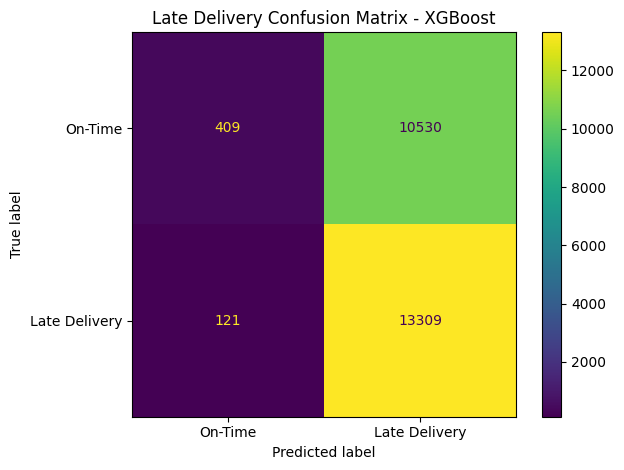

In [85]:
# ============================================================
# STEP 14 — CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

print(

    classification_report(

        y_test_late,

        late_test_prediction,

        target_names=[
            "On-Time",
            "Late Delivery"
        ]

    )

)


ConfusionMatrixDisplay.from_predictions(

    y_test_late,

    late_test_prediction,

    display_labels=[
        "On-Time",
        "Late Delivery"
    ]

)

plt.title(
    f"Late Delivery Confusion Matrix - {late_winner_name}"
)

plt.tight_layout()
plt.show()

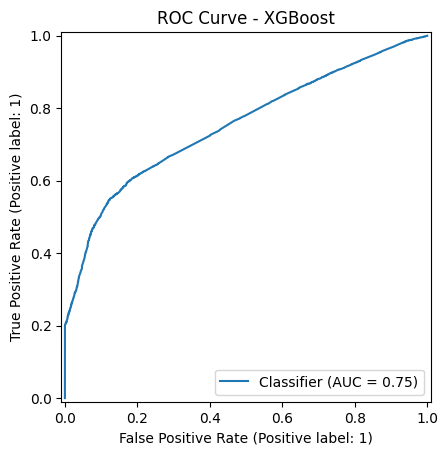

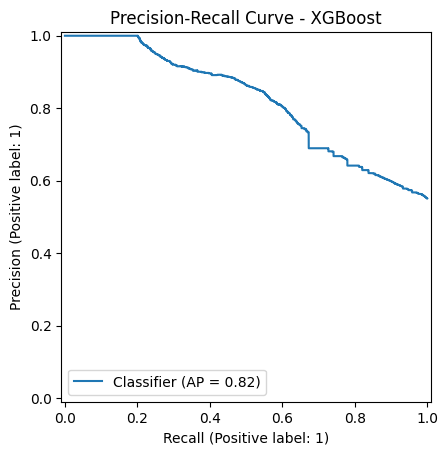

In [86]:
# ============================================================
# STEP 15 — ROC + PR CURVES
# ============================================================

from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RocCurveDisplay.from_predictions(

    y_test_late,

    late_test_probability

)

plt.title(
    f"ROC Curve - {late_winner_name}"
)

plt.show()


PrecisionRecallDisplay.from_predictions(

    y_test_late,

    late_test_probability

)

plt.title(
    f"Precision-Recall Curve - {late_winner_name}"
)

plt.show()

In [87]:
# ============================================================
# STEP 16 — FEATURE IMPORTANCE
# ============================================================

if late_best_type == "catboost":

    late_feature_names = (
        LATE_FEATURES
    )

    late_feature_importance = (
        late_best_model
        .get_feature_importance()
    )

else:

    fitted_prep = (
        late_best_model
        .named_steps["prep"]
    )

    fitted_estimator = (
        late_best_model
        .named_steps["model"]
    )

    late_feature_names = (
        fitted_prep
        .get_feature_names_out()
    )

    if hasattr(
        fitted_estimator,
        "feature_importances_"
    ):

        late_feature_importance = (
            fitted_estimator
            .feature_importances_
        )

    else:

        late_feature_importance = (
            np.abs(
                fitted_estimator.coef_[0]
            )
        )


late_importance_df = pd.DataFrame({

    "Feature":
        late_feature_names,

    "Importance":
        late_feature_importance

})


late_importance_df = (

    late_importance_df

    .sort_values(
        "Importance",
        ascending=False
    )

    .reset_index(drop=True)

)


display(
    late_importance_df.head(20)
)

,Feature,Importance
0,categorical__Shipping Mode_Standard Class,0.151308
1,categorical__Shipping Mode_First Class,0.087514
2,numeric__Days for shipment (scheduled),0.081347
3,categorical__Shipping Mode_Same Day,0.040181
4,categorical__Shipping Mode_Second Class,0.035604
5,categorical__Type_TRANSFER,0.008561
6,categorical__Order Country_China,0.003250
7,categorical__Order State_Kentucky,0.002682
8,categorical__Type_CASH,0.002635
9,categorical__Type_PAYMENT,0.002562


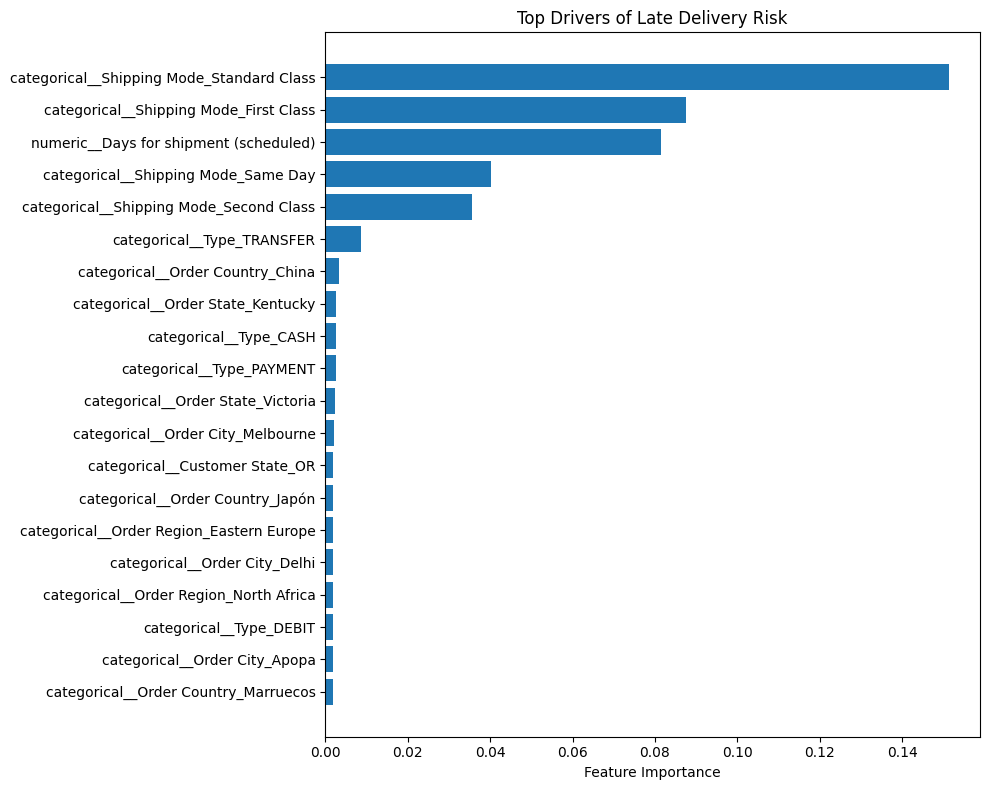

In [88]:
top20 = (

    late_importance_df
    .head(20)
    .sort_values("Importance")

)

plt.figure(
    figsize=(10, 8)
)

plt.barh(

    top20["Feature"],

    top20["Importance"]

)

plt.xlabel(
    "Feature Importance"
)

plt.title(
    "Top Drivers of Late Delivery Risk"
)

plt.tight_layout()

plt.show()

In [89]:
# ============================================================
# STEP 17 — TOP 10% RISK LIFT
# ============================================================

late_lift = pd.DataFrame({

    "Actual_Late":
        y_test_late.values,

    "Late_Risk_Probability":
        late_test_probability

})


late_lift = (

    late_lift

    .sort_values(
        "Late_Risk_Probability",
        ascending=False
    )

    .reset_index(drop=True)

)


top_n = max(
    1,
    int(len(late_lift) * 0.10)
)


overall_rate = (
    late_lift[
        "Actual_Late"
    ].mean()
)


top10_rate = (

    late_lift
    .head(top_n)[
        "Actual_Late"
    ]
    .mean()

)


top10_lift = (
    top10_rate /
    overall_rate
)


print(
    "Overall Late Delivery Rate:",
    round(overall_rate, 4)
)

print(
    "Top 10% Risk Late Rate:",
    round(top10_rate, 4)
)

print(
    "Top 10% Lift:",
    round(top10_lift, 2),
    "x"
)

Overall Late Delivery Rate: 0.5511
Top 10% Risk Late Rate: 1.0
Top 10% Lift: 1.81 x


In [90]:
# ============================================================
# STEP 18 — COGNOS READY DATA
# ============================================================

late_scored = late_test[

    [

        "Order Id",
        "Market",
        "Order Region",
        "Order Country",
        "Category Name",
        "Department Name",
        "Customer Segment",
        "Shipping Mode",
        "Order_Date",
        "Late_delivery_risk"

    ]

].copy()


late_scored.rename(

    columns={

        "Late_delivery_risk":
            "Actual_Late_Delivery"

    },

    inplace=True

)


late_scored[
    "Late_Delivery_Probability"
] = late_test_probability


late_scored[
    "Predicted_Late_Delivery"
] = late_test_prediction


late_scored[
    "Correct_Prediction"
] = (

    late_scored[
        "Actual_Late_Delivery"
    ]

    ==

    late_scored[
        "Predicted_Late_Delivery"
    ]

).astype(int)


late_scored[
    "Delivery_Risk_Level"
] = pd.cut(

    late_test_probability,

    bins=[
        -np.inf,
        0.35,
        0.65,
        np.inf
    ],

    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]

)


display(
    late_scored.head(10)
)

,Order Id,Market,Order Region,Order Country,Category Name,Department Name,Customer Segment,Shipping Mode,Order_Date,Actual_Late_Delivery,Late_Delivery_Probability,Predicted_Late_Delivery,Correct_Prediction,Delivery_Risk_Level
156150,62477,Europe,Western Europe,Francia,Golf Shoes,Outdoors,Corporate,Standard Class,2017-07-01 00:07:00,0,0.419674,1,0,Medium Risk
156151,62477,Europe,Western Europe,Francia,Cleats,Apparel,Corporate,Standard Class,2017-07-01 00:07:00,0,0.419674,1,0,Medium Risk
156152,62477,Europe,Western Europe,Francia,Indoor/Outdoor Games,Fan Shop,Corporate,Standard Class,2017-07-01 00:07:00,0,0.419674,1,0,Medium Risk
156153,62478,Europe,Western Europe,Francia,Fishing,Fan Shop,Consumer,Standard Class,2017-07-01 00:28:00,0,0.446549,1,0,Medium Risk
156154,62478,Europe,Western Europe,Francia,Fishing,Fan Shop,Consumer,Standard Class,2017-07-01 00:28:00,0,0.446549,1,0,Medium Risk
156155,62478,Europe,Western Europe,Francia,Water Sports,Fan Shop,Consumer,Standard Class,2017-07-01 00:28:00,0,0.446549,1,0,Medium Risk
156156,62478,Europe,Western Europe,Francia,Women's Apparel,Golf,Consumer,Standard Class,2017-07-01 00:28:00,0,0.428724,1,0,Medium Risk
156157,62479,Europe,Western Europe,Francia,Shop By Sport,Golf,Consumer,Standard Class,2017-07-01 00:49:00,1,0.368898,1,1,Medium Risk
156158,62479,Europe,Western Europe,Francia,Women's Apparel,Golf,Consumer,Standard Class,2017-07-01 00:49:00,1,0.368898,1,1,Medium Risk
156159,62479,Europe,Western Europe,Francia,Indoor/Outdoor Games,Fan Shop,Consumer,Standard Class,2017-07-01 00:49:00,1,0.372180,1,1,Medium Risk


In [91]:
# ============================================================
# STEP 19 — SAVE FINAL PROJECT
# ============================================================

from pathlib import Path
import joblib

FINAL_DIR = Path(
    "/content/DataCo_Final_Project"
)

FINAL_DIR.mkdir(
    exist_ok=True
)


late_scored.to_csv(

    FINAL_DIR /
    "Late_Delivery_Scored_Orders.csv",

    index=False
)


late_comparison.to_csv(

    FINAL_DIR /
    "Late_Delivery_Model_Comparison.csv",

    index=False
)


late_threshold_df.to_csv(

    FINAL_DIR /
    "Late_Delivery_Threshold_Analysis.csv",

    index=False
)


late_importance_df.to_csv(

    FINAL_DIR /
    "Late_Delivery_Feature_Importance.csv",

    index=False
)


joblib.dump(

    late_best_model,

    FINAL_DIR /
    "Final_Late_Delivery_Model.pkl"

)


with open(

    FINAL_DIR /
    "Winning_Model.txt",

    "w"

) as f:

    f.write(
        late_winner_name
    )


with open(

    FINAL_DIR /
    "Best_Threshold.txt",

    "w"

) as f:

    f.write(
        str(late_best_threshold)
    )


print(
    "✅ FINAL PROJECT FILES SAVED"
)

for file in sorted(
    FINAL_DIR.iterdir()
):

    print(
        "✓",
        file.name
    )

✅ FINAL PROJECT FILES SAVED
✓ Best_Threshold.txt
✓ Final_Late_Delivery_Model.pkl
✓ Late_Delivery_Feature_Importance.csv
✓ Late_Delivery_Model_Comparison.csv
✓ Late_Delivery_Scored_Orders.csv
✓ Late_Delivery_Threshold_Analysis.csv
✓ Winning_Model.txt


In [92]:
# ============================================================
# STEP 20 — ZIP
# ============================================================

import shutil
from google.colab import files

zip_path = shutil.make_archive(

    "/content/DataCo_Final_Project",

    "zip",

    FINAL_DIR

)

print(
    "✅ ZIP created:",
    zip_path
)

files.download(
    zip_path
)

✅ ZIP created: /content/DataCo_Final_Project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Preprocessor ready

Training: Logistic Regression

Training: Random Forest

Training: XGBoost

FINAL MODEL COMPARISON


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,XGBoost,0.6878,0.7011,0.8244,0.5368,0.6502,0.7306,0.8018,0.4198
1,Random Forest,0.6841,0.6940,0.7856,0.5714,0.6616,0.7275,0.8008,0.3959
2,Logistic Regression,0.6833,0.6930,0.7826,0.5733,0.6618,0.7259,0.7918,0.3932
3,CatBoost,0.6861,0.6995,0.8231,0.5339,0.6477,0.7229,0.7952,0.4167



🏆 WINNER: XGBoost

🎯 BEST THRESHOLD: 0.32


,Threshold,Precision,Recall,F1,Balanced_Accuracy,MCC
12,0.32,0.545042,0.990974,0.703277,0.508953,0.068528
11,0.31,0.544015,0.994082,0.703201,0.506956,0.062876
13,0.33,0.546703,0.984877,0.703111,0.512127,0.075580
10,0.30,0.542435,0.997549,0.702741,0.503838,0.049621
9,0.29,0.542102,0.998266,0.702640,0.503177,0.046525
8,0.28,0.541505,0.999044,0.702330,0.501983,0.037546
7,0.27,0.541188,0.999462,0.702167,0.501348,0.031908
6,0.26,0.540849,1.000000,0.702014,0.500668,0.026881
5,0.25,0.540744,1.000000,0.701926,0.500457,0.022233
4,0.24,0.540744,1.000000,0.701926,0.500457,0.022233



🏆 FINAL TEST RESULTS
Winning Model: XGBoost
Best Threshold: 0.32
Accuracy: 0.5647
Balanced_Accuracy: 0.5163
Precision: 0.5594
Recall: 0.9894
F1: 0.7147
ROC_AUC: 0.7536
PR_AUC: 0.8195
MCC: 0.1034

CLASSIFICATION REPORT
               precision    recall  f1-score   support

      On-Time       0.77      0.04      0.08     10939
Late Delivery       0.56      0.99      0.71     13430

     accuracy                           0.56     24369
    macro avg       0.66      0.52      0.40     24369
 weighted avg       0.65      0.56      0.43     24369



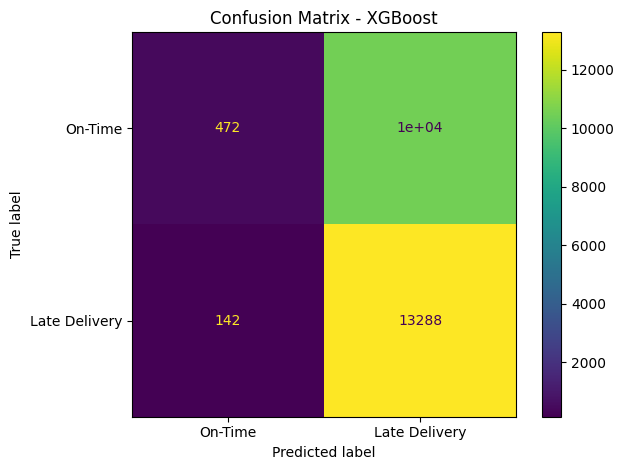

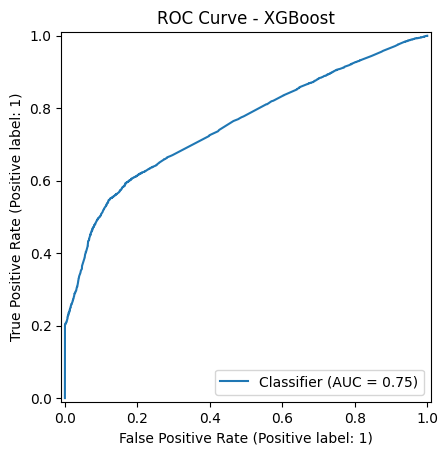

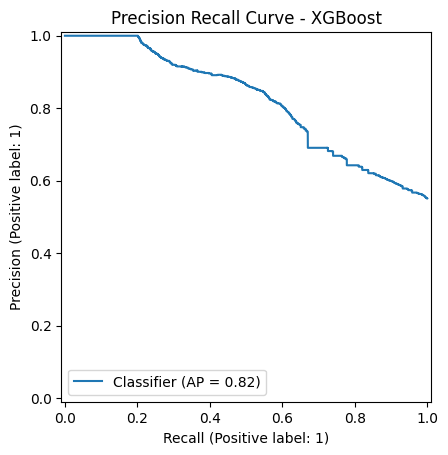


TOP FEATURES


,Feature,Importance
0,categorical__Shipping Mode_Standard Class,0.158488
1,categorical__Shipping Mode_First Class,0.087685
2,numeric__Days for shipment (scheduled),0.084211
3,categorical__Shipping Mode_Same Day,0.040259
4,categorical__Shipping Mode_Second Class,0.035673
5,categorical__Type_TRANSFER,0.008772
6,categorical__Order Country_China,0.003257
7,categorical__Order State_Kentucky,0.002687
8,categorical__Type_CASH,0.002640
9,categorical__Type_PAYMENT,0.002607


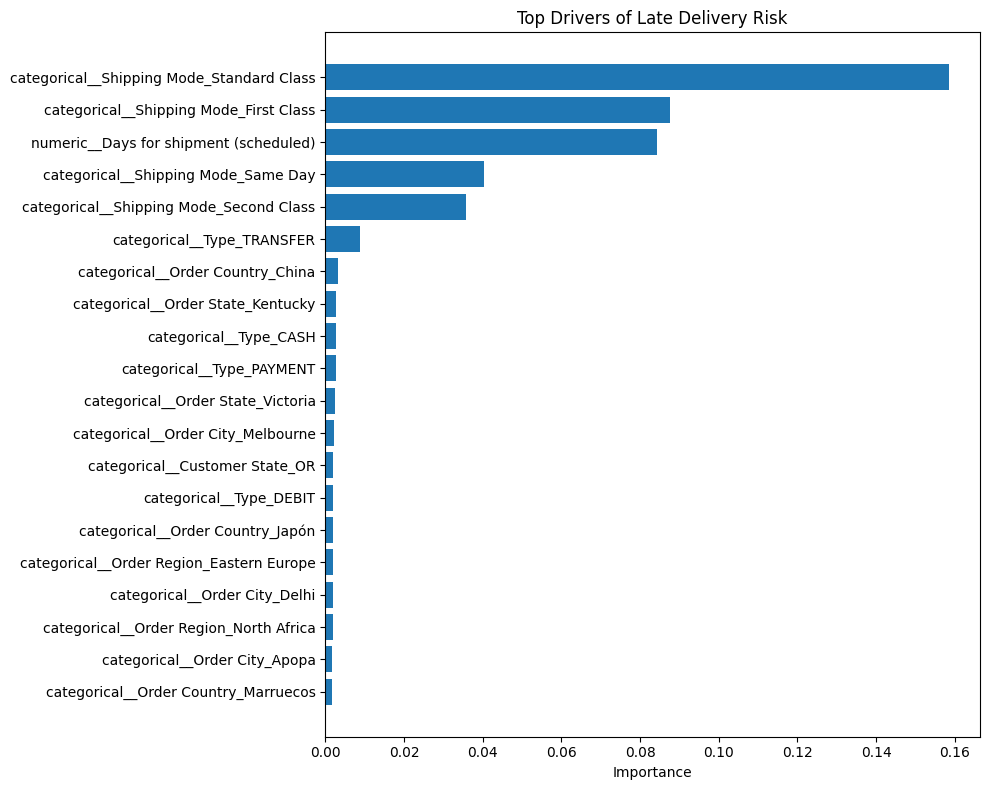


TOP 10% RISK LIFT
Overall Late Rate: 0.5511
Top 10% Risk Late Rate: 1.0
Lift: 1.81 x

SCORED DATASET


,Order Id,Market,Order Region,Order Country,Category Name,Department Name,Customer Segment,Shipping Mode,Order_Date,Actual_Late_Delivery,Late_Delivery_Probability,Predicted_Late_Delivery,Correct_Prediction,Delivery_Risk_Level
156150,62477,Europe,Western Europe,Francia,Golf Shoes,Outdoors,Corporate,Standard Class,2017-07-01 00:07:00,0,0.419820,1,0,Medium Risk
156151,62477,Europe,Western Europe,Francia,Cleats,Apparel,Corporate,Standard Class,2017-07-01 00:07:00,0,0.419820,1,0,Medium Risk
156152,62477,Europe,Western Europe,Francia,Indoor/Outdoor Games,Fan Shop,Corporate,Standard Class,2017-07-01 00:07:00,0,0.419820,1,0,Medium Risk
156153,62478,Europe,Western Europe,Francia,Fishing,Fan Shop,Consumer,Standard Class,2017-07-01 00:28:00,0,0.446697,1,0,Medium Risk
156154,62478,Europe,Western Europe,Francia,Fishing,Fan Shop,Consumer,Standard Class,2017-07-01 00:28:00,0,0.446697,1,0,Medium Risk
156155,62478,Europe,Western Europe,Francia,Water Sports,Fan Shop,Consumer,Standard Class,2017-07-01 00:28:00,0,0.446697,1,0,Medium Risk
156156,62478,Europe,Western Europe,Francia,Women's Apparel,Golf,Consumer,Standard Class,2017-07-01 00:28:00,0,0.428870,1,0,Medium Risk
156157,62479,Europe,Western Europe,Francia,Shop By Sport,Golf,Consumer,Standard Class,2017-07-01 00:49:00,1,0.369037,1,1,Medium Risk
156158,62479,Europe,Western Europe,Francia,Women's Apparel,Golf,Consumer,Standard Class,2017-07-01 00:49:00,1,0.369037,1,1,Medium Risk
156159,62479,Europe,Western Europe,Francia,Indoor/Outdoor Games,Fan Shop,Consumer,Standard Class,2017-07-01 00:49:00,1,0.372319,1,1,Medium Risk



FINAL PROJECT SUMMARY


,Property,Value
0,Winning Model,XGBoost
1,Best Threshold,0.32
2,Accuracy,0.5647
3,Balanced Accuracy,0.5163
4,Precision,0.5594
5,Recall,0.9894
6,F1,0.7147
7,ROC-AUC,0.7536
8,PR-AUC,0.8195
9,MCC,0.1034



✅ ALL FINAL FILES SAVED
✓ Best_Threshold.txt
✓ Final_Late_Delivery_Model.pkl
✓ Late_Delivery_Feature_Importance.csv
✓ Late_Delivery_Final_Summary.csv
✓ Late_Delivery_Model_Comparison.csv
✓ Late_Delivery_Scored_Orders.csv
✓ Late_Delivery_Threshold_Analysis.csv
✓ Winning_Model.txt

✅ ZIP CREATED: /content/DataCo_Final_Project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [93]:
# ============================================================
# FINAL LATE DELIVERY PIPELINE — CONTINUE FROM CURRENT NOTEBOOK
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shutil

from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ============================================================
# 1. PREPROCESSOR FOR LR / RF / XGB
# ============================================================

late_num_pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

late_cat_pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=5
        )
    )
])

late_preprocessor = ColumnTransformer([
    (
        "numeric",
        late_num_pipe,
        LATE_NUMERIC
    ),
    (
        "categorical",
        late_cat_pipe,
        LATE_CATEGORICAL
    )
])

print("✅ Preprocessor ready")


# ============================================================
# 2. CREATE 3 OTHER MODELS
# ============================================================

late_models = {

    "Logistic Regression": Pipeline([
        ("prep", late_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        ("prep", late_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=220,
                max_depth=14,
                min_samples_leaf=5,
                class_weight="balanced",
                n_jobs=-1,
                random_state=42
            )
        )
    ]),

    "XGBoost": Pipeline([
        ("prep", late_preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=280,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=3,
                eval_metric="logloss",
                tree_method="hist",
                n_jobs=-1,
                random_state=42
            )
        )
    ])
}


# ============================================================
# 3. TRAIN + VALIDATION COMPARISON
# ============================================================

late_results = []
late_registry = {}

for name, model in late_models.items():

    print("\nTraining:", name)

    model.fit(
        X_train_late,
        y_train_late
    )

    prob = model.predict_proba(
        X_val_late
    )[:, 1]

    pred = (
        prob >= 0.50
    ).astype(int)

    late_results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_val_late,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_val_late,
                pred
            ),

        "Precision":
            precision_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_val_late,
                prob
            ),

        "PR_AUC":
            average_precision_score(
                y_val_late,
                prob
            ),

        "MCC":
            matthews_corrcoef(
                y_val_late,
                pred
            )
    })

    late_registry[name] = {
        "model": model,
        "type": "pipeline"
    }


# ============================================================
# 4. ADD EXISTING CATBOOST
# ============================================================

cat_prob = late_catboost.predict_proba(
    X_val_late_cat
)[:, 1]

cat_pred = (
    cat_prob >= 0.50
).astype(int)

late_results.append({

    "Model": "CatBoost",

    "Accuracy":
        accuracy_score(
            y_val_late,
            cat_pred
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_val_late,
            cat_pred
        ),

    "Precision":
        precision_score(
            y_val_late,
            cat_pred,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_val_late,
            cat_pred,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_val_late,
            cat_pred,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_val_late,
            cat_prob
        ),

    "PR_AUC":
        average_precision_score(
            y_val_late,
            cat_prob
        ),

    "MCC":
        matthews_corrcoef(
            y_val_late,
            cat_pred
        )
})

late_registry["CatBoost"] = {
    "model": late_catboost,
    "type": "catboost"
}


# ============================================================
# 5. MODEL COMPARISON
# ============================================================

late_comparison = (
    pd.DataFrame(
        late_results
    )
    .sort_values(
        ["ROC_AUC", "PR_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n======================================")
print("FINAL MODEL COMPARISON")
print("======================================")

display(
    late_comparison.round(4)
)


# ============================================================
# 6. SELECT WINNER
# ============================================================

late_winner_name = (
    late_comparison
    .iloc[0]["Model"]
)

late_winner_info = (
    late_registry[
        late_winner_name
    ]
)

late_best_model = (
    late_winner_info[
        "model"
    ]
)

late_best_type = (
    late_winner_info[
        "type"
    ]
)

print("\n🏆 WINNER:", late_winner_name)


# ============================================================
# 7. WINNER VALIDATION PROBABILITY
# ============================================================

if late_best_type == "catboost":

    late_winner_val_prob = (
        late_best_model
        .predict_proba(
            X_val_late_cat
        )[:, 1]
    )

else:

    late_winner_val_prob = (
        late_best_model
        .predict_proba(
            X_val_late
        )[:, 1]
    )


# ============================================================
# 8. THRESHOLD OPTIMIZATION
# ============================================================

threshold_rows = []

for threshold in np.arange(
    0.20,
    0.81,
    0.01
):

    pred = (
        late_winner_val_prob
        >= threshold
    ).astype(int)

    threshold_rows.append({

        "Threshold":
            round(
                float(threshold),
                2
            ),

        "Precision":
            precision_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_val_late,
                pred
            ),

        "MCC":
            matthews_corrcoef(
                y_val_late,
                pred
            )
    })

late_threshold_df = pd.DataFrame(
    threshold_rows
)

late_best_threshold = float(

    late_threshold_df.loc[

        late_threshold_df[
            "F1"
        ].idxmax(),

        "Threshold"

    ]
)

print(
    "\n🎯 BEST THRESHOLD:",
    late_best_threshold
)

display(
    late_threshold_df
    .sort_values(
        "F1",
        ascending=False
    )
    .head(10)
)


# ============================================================
# 9. FINAL UNTOUCHED TEST
# ============================================================

if late_best_type == "catboost":

    late_test_probability = (
        late_best_model
        .predict_proba(
            X_test_late_cat
        )[:, 1]
    )

else:

    late_test_probability = (
        late_best_model
        .predict_proba(
            X_test_late
        )[:, 1]
    )

late_test_prediction = (
    late_test_probability
    >= late_best_threshold
).astype(int)


late_final_metrics = {

    "Accuracy":
        accuracy_score(
            y_test_late,
            late_test_prediction
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_test_late,
            late_test_prediction
        ),

    "Precision":
        precision_score(
            y_test_late,
            late_test_prediction,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_test_late,
            late_test_prediction,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_test_late,
            late_test_prediction,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_test_late,
            late_test_probability
        ),

    "PR_AUC":
        average_precision_score(
            y_test_late,
            late_test_probability
        ),

    "MCC":
        matthews_corrcoef(
            y_test_late,
            late_test_prediction
        )
}

print("\n======================================")
print("🏆 FINAL TEST RESULTS")
print("======================================")

print(
    "Winning Model:",
    late_winner_name
)

print(
    "Best Threshold:",
    late_best_threshold
)

for metric, value in late_final_metrics.items():

    print(
        f"{metric}: {value:.4f}"
    )


# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

print("\n======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_test_late,
        late_test_prediction,
        target_names=[
            "On-Time",
            "Late Delivery"
        ]
    )
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

ConfusionMatrixDisplay.from_predictions(

    y_test_late,

    late_test_prediction,

    display_labels=[
        "On-Time",
        "Late Delivery"
    ]
)

plt.title(
    f"Confusion Matrix - {late_winner_name}"
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. ROC CURVE
# ============================================================

RocCurveDisplay.from_predictions(

    y_test_late,

    late_test_probability

)

plt.title(
    f"ROC Curve - {late_winner_name}"
)

plt.show()


# ============================================================
# 13. PRECISION RECALL CURVE
# ============================================================

PrecisionRecallDisplay.from_predictions(

    y_test_late,

    late_test_probability

)

plt.title(
    f"Precision Recall Curve - {late_winner_name}"
)

plt.show()


# ============================================================
# 14. FEATURE IMPORTANCE
# ============================================================

if late_best_type == "catboost":

    late_feature_names = (
        LATE_FEATURES
    )

    late_feature_importance = (
        late_best_model
        .get_feature_importance()
    )

else:

    fitted_prep = (
        late_best_model
        .named_steps["prep"]
    )

    fitted_estimator = (
        late_best_model
        .named_steps["model"]
    )

    late_feature_names = (
        fitted_prep
        .get_feature_names_out()
    )

    if hasattr(
        fitted_estimator,
        "feature_importances_"
    ):

        late_feature_importance = (
            fitted_estimator
            .feature_importances_
        )

    else:

        late_feature_importance = (
            np.abs(
                fitted_estimator
                .coef_[0]
            )
        )


late_importance_df = pd.DataFrame({

    "Feature":
        late_feature_names,

    "Importance":
        late_feature_importance

})


late_importance_df = (

    late_importance_df

    .sort_values(
        "Importance",
        ascending=False
    )

    .reset_index(drop=True)

)

print("\nTOP FEATURES")

display(
    late_importance_df.head(20)
)


top20 = (
    late_importance_df
    .head(20)
    .sort_values("Importance")
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel(
    "Importance"
)

plt.title(
    "Top Drivers of Late Delivery Risk"
)

plt.tight_layout()
plt.show()


# ============================================================
# 15. TOP 10% RISK LIFT
# ============================================================

late_lift = pd.DataFrame({

    "Actual_Late":
        y_test_late.values,

    "Late_Risk_Probability":
        late_test_probability

})


late_lift = (

    late_lift

    .sort_values(
        "Late_Risk_Probability",
        ascending=False
    )

    .reset_index(drop=True)

)


top_n = max(
    1,
    int(
        len(late_lift)
        * 0.10
    )
)


overall_rate = (
    late_lift[
        "Actual_Late"
    ].mean()
)


top10_rate = (

    late_lift
    .head(top_n)[
        "Actual_Late"
    ]
    .mean()

)


top10_lift = (
    top10_rate
    /
    overall_rate
)


print("\n======================================")
print("TOP 10% RISK LIFT")
print("======================================")

print(
    "Overall Late Rate:",
    round(
        overall_rate,
        4
    )
)

print(
    "Top 10% Risk Late Rate:",
    round(
        top10_rate,
        4
    )
)

print(
    "Lift:",
    round(
        top10_lift,
        2
    ),
    "x"
)


# ============================================================
# 16. FINAL SCORED DATASET
# ============================================================

late_scored = late_test[

    [

        "Order Id",
        "Market",
        "Order Region",
        "Order Country",
        "Category Name",
        "Department Name",
        "Customer Segment",
        "Shipping Mode",
        "Order_Date",
        "Late_delivery_risk"

    ]

].copy()


late_scored.rename(

    columns={

        "Late_delivery_risk":
            "Actual_Late_Delivery"

    },

    inplace=True

)


late_scored[
    "Late_Delivery_Probability"
] = late_test_probability


late_scored[
    "Predicted_Late_Delivery"
] = late_test_prediction


late_scored[
    "Correct_Prediction"
] = (

    late_scored[
        "Actual_Late_Delivery"
    ]

    ==

    late_scored[
        "Predicted_Late_Delivery"
    ]

).astype(int)


late_scored[
    "Delivery_Risk_Level"
] = pd.cut(

    late_test_probability,

    bins=[
        -np.inf,
        0.35,
        0.65,
        np.inf
    ],

    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]

)


print("\nSCORED DATASET")

display(
    late_scored.head(10)
)


# ============================================================
# 17. FINAL SUMMARY
# ============================================================

late_summary = pd.DataFrame({

    "Property": [

        "Winning Model",
        "Best Threshold",

        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "MCC",

        "Overall Late Rate",
        "Top 10% Risk Late Rate",
        "Top 10% Lift",

        "Training Rows",
        "Validation Rows",
        "Testing Rows"

    ],

    "Value": [

        late_winner_name,

        late_best_threshold,

        round(
            late_final_metrics[
                "Accuracy"
            ],
            4
        ),

        round(
            late_final_metrics[
                "Balanced_Accuracy"
            ],
            4
        ),

        round(
            late_final_metrics[
                "Precision"
            ],
            4
        ),

        round(
            late_final_metrics[
                "Recall"
            ],
            4
        ),

        round(
            late_final_metrics[
                "F1"
            ],
            4
        ),

        round(
            late_final_metrics[
                "ROC_AUC"
            ],
            4
        ),

        round(
            late_final_metrics[
                "PR_AUC"
            ],
            4
        ),

        round(
            late_final_metrics[
                "MCC"
            ],
            4
        ),

        round(
            overall_rate,
            4
        ),

        round(
            top10_rate,
            4
        ),

        round(
            top10_lift,
            2
        ),

        len(
            late_train
        ),

        len(
            late_val
        ),

        len(
            late_test
        )
    ]

})


print("\nFINAL PROJECT SUMMARY")

display(
    late_summary
)


# ============================================================
# 18. SAVE EVERYTHING
# ============================================================

FINAL_DIR = Path(
    "/content/DataCo_Final_Project"
)

FINAL_DIR.mkdir(
    exist_ok=True
)


late_scored.to_csv(

    FINAL_DIR /
    "Late_Delivery_Scored_Orders.csv",

    index=False
)


late_comparison.to_csv(

    FINAL_DIR /
    "Late_Delivery_Model_Comparison.csv",

    index=False
)


late_threshold_df.to_csv(

    FINAL_DIR /
    "Late_Delivery_Threshold_Analysis.csv",

    index=False
)


late_importance_df.to_csv(

    FINAL_DIR /
    "Late_Delivery_Feature_Importance.csv",

    index=False
)


late_summary.to_csv(

    FINAL_DIR /
    "Late_Delivery_Final_Summary.csv",

    index=False
)


joblib.dump(

    late_best_model,

    FINAL_DIR /
    "Final_Late_Delivery_Model.pkl"

)


with open(

    FINAL_DIR /
    "Winning_Model.txt",

    "w"

) as f:

    f.write(
        str(
            late_winner_name
        )
    )


with open(

    FINAL_DIR /
    "Best_Threshold.txt",

    "w"

) as f:

    f.write(
        str(
            late_best_threshold
        )
    )


print("\n======================================")
print("✅ ALL FINAL FILES SAVED")
print("======================================")

for file in sorted(
    FINAL_DIR.iterdir()
):

    print(
        "✓",
        file.name
    )


# ============================================================
# 19. ZIP DOWNLOAD
# ============================================================

zip_path = shutil.make_archive(

    "/content/DataCo_Final_Project",

    "zip",

    FINAL_DIR

)


print(
    "\n✅ ZIP CREATED:",
    zip_path
)


from google.colab import files

files.download(
    zip_path
)

FINAL THRESHOLD SELECTION
Best MCC Threshold: 0.56


,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC
36,0.56,0.687431,0.701511,0.832689,0.527766,0.646056,0.423217
37,0.57,0.687044,0.701152,0.832499,0.527049,0.645461,0.422579
45,0.65,0.685816,0.700338,0.835778,0.521131,0.641973,0.422427
38,0.58,0.686785,0.700929,0.832561,0.526391,0.644986,0.422244
44,0.64,0.685848,0.700325,0.835279,0.521669,0.642234,0.422232
46,0.66,0.685428,0.700032,0.836234,0.519816,0.641109,0.422101
39,0.59,0.686494,0.700670,0.832544,0.525734,0.644488,0.421825
43,0.63,0.685719,0.700148,0.834512,0.522087,0.642324,0.421680
40,0.60,0.686204,0.700454,0.833033,0.524598,0.643779,0.421650
35,0.55,0.686947,0.700925,0.830827,0.528424,0.645986,0.421637



🏆 TRUE FINAL TEST RESULTS
Winning Model: XGBoost
Final Threshold: 0.56
Accuracy: 0.6949
Balanced_Accuracy: 0.7120
Precision: 0.8475
Recall: 0.5443
F1: 0.6629
ROC_AUC: 0.7536
PR_AUC: 0.8195
MCC: 0.4411

CLASSIFICATION REPORT
               precision    recall  f1-score   support

      On-Time       0.61      0.88      0.72     10939
Late Delivery       0.85      0.54      0.66     13430

     accuracy                           0.69     24369
    macro avg       0.73      0.71      0.69     24369
 weighted avg       0.74      0.69      0.69     24369



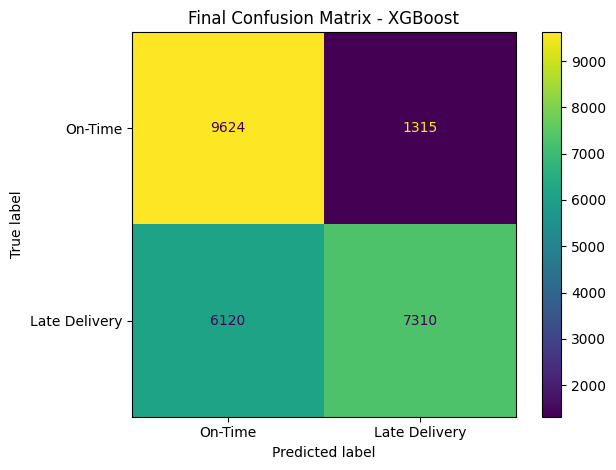

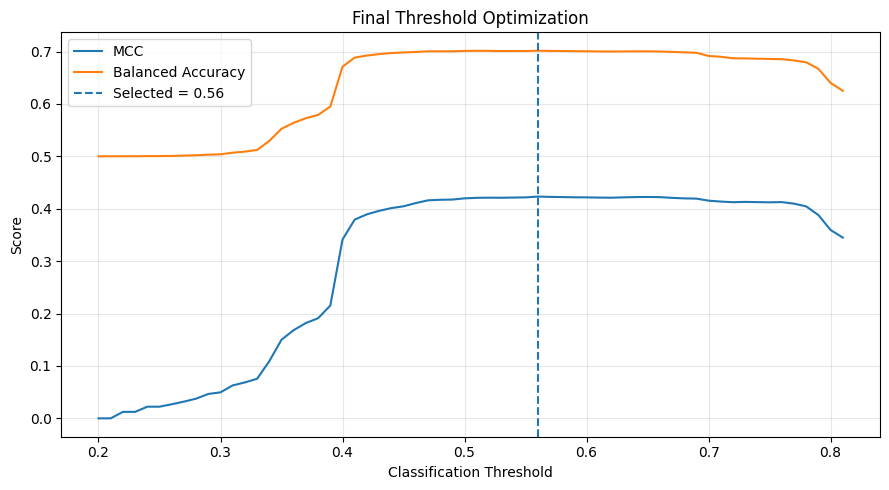


FINAL PROJECT SUMMARY


,Property,Value
0,Winning Model,XGBoost
1,Final Threshold,0.56
2,Threshold Criterion,Maximum Validation MCC
3,Accuracy,0.6949
4,Balanced Accuracy,0.712
5,Precision,0.8475
6,Recall,0.5443
7,F1,0.6629
8,ROC-AUC,0.7536
9,PR-AUC,0.8195



✅ FINAL PROJECT COMPLETE
Model: XGBoost
Threshold: 0.56
ROC-AUC: 0.7536
PR-AUC: 0.8195
Balanced Accuracy: 0.712
MCC: 0.4411

ZIP: /content/DataCo_Final_Project_FINAL.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [94]:
# ============================================================
# FINAL THRESHOLD FIX — OPTIMIZE MCC
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shutil

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    classification_report,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. Search threshold on VALIDATION only
# ------------------------------------------------------------

final_threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.01):

    pred = (
        late_winner_val_prob >= threshold
    ).astype(int)

    final_threshold_rows.append({

        "Threshold": round(float(threshold), 2),

        "Accuracy":
            accuracy_score(
                y_val_late,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_val_late,
                pred
            ),

        "Precision":
            precision_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val_late,
                pred,
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                y_val_late,
                pred
            )
    })


final_threshold_df = pd.DataFrame(
    final_threshold_rows
)


# ------------------------------------------------------------
# 2. Select threshold by MCC
# ------------------------------------------------------------

final_best_threshold = float(

    final_threshold_df.loc[

        final_threshold_df[
            "MCC"
        ].idxmax(),

        "Threshold"

    ]
)


print("======================================")
print("FINAL THRESHOLD SELECTION")
print("======================================")

print(
    "Best MCC Threshold:",
    final_best_threshold
)


display(

    final_threshold_df
    .sort_values(
        "MCC",
        ascending=False
    )
    .head(15)
)


# ------------------------------------------------------------
# 3. FINAL TEST predictions
# ------------------------------------------------------------

final_test_prediction = (

    late_test_probability
    >= final_best_threshold

).astype(int)


# ------------------------------------------------------------
# 4. FINAL metrics
# ------------------------------------------------------------

FINAL_METRICS = {

    "Accuracy":
        accuracy_score(
            y_test_late,
            final_test_prediction
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_test_late,
            final_test_prediction
        ),

    "Precision":
        precision_score(
            y_test_late,
            final_test_prediction,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_test_late,
            final_test_prediction,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_test_late,
            final_test_prediction,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_test_late,
            late_test_probability
        ),

    "PR_AUC":
        average_precision_score(
            y_test_late,
            late_test_probability
        ),

    "MCC":
        matthews_corrcoef(
            y_test_late,
            final_test_prediction
        )
}


print("\n======================================")
print("🏆 TRUE FINAL TEST RESULTS")
print("======================================")

print(
    "Winning Model:",
    late_winner_name
)

print(
    "Final Threshold:",
    final_best_threshold
)

for metric, value in FINAL_METRICS.items():

    print(
        f"{metric}: {value:.4f}"
    )


# ------------------------------------------------------------
# 5. Classification report
# ------------------------------------------------------------

print("\n======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(

    classification_report(

        y_test_late,

        final_test_prediction,

        target_names=[
            "On-Time",
            "Late Delivery"
        ]

    )
)


# ------------------------------------------------------------
# 6. Confusion Matrix
# ------------------------------------------------------------

ConfusionMatrixDisplay.from_predictions(

    y_test_late,

    final_test_prediction,

    display_labels=[
        "On-Time",
        "Late Delivery"
    ]

)

plt.title(
    f"Final Confusion Matrix - {late_winner_name}"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 7. Threshold chart
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    final_threshold_df["Threshold"],
    final_threshold_df["MCC"],
    label="MCC"
)

plt.plot(
    final_threshold_df["Threshold"],
    final_threshold_df["Balanced_Accuracy"],
    label="Balanced Accuracy"
)

plt.axvline(
    final_best_threshold,
    linestyle="--",
    label=f"Selected = {final_best_threshold}"
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Final Threshold Optimization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 8. Update scored dataset
# ------------------------------------------------------------

late_scored[
    "Predicted_Late_Delivery"
] = final_test_prediction


late_scored[
    "Correct_Prediction"
] = (

    late_scored[
        "Actual_Late_Delivery"
    ]

    ==

    late_scored[
        "Predicted_Late_Delivery"
    ]

).astype(int)


# Dynamic risk levels based on probabilities

late_scored[
    "Delivery_Risk_Level"
] = pd.cut(

    late_test_probability,

    bins=[
        -np.inf,
        max(
            0,
            final_best_threshold - 0.15
        ),
        min(
            1,
            final_best_threshold + 0.15
        ),
        np.inf
    ],

    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]

)


# ------------------------------------------------------------
# 9. Final summary
# ------------------------------------------------------------

final_summary = pd.DataFrame({

    "Property": [

        "Winning Model",
        "Final Threshold",
        "Threshold Criterion",

        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "MCC",

        "Top 10% Risk Lift",

        "Training Rows",
        "Validation Rows",
        "Testing Rows"

    ],

    "Value": [

        late_winner_name,

        final_best_threshold,

        "Maximum Validation MCC",

        round(
            FINAL_METRICS["Accuracy"],
            4
        ),

        round(
            FINAL_METRICS["Balanced_Accuracy"],
            4
        ),

        round(
            FINAL_METRICS["Precision"],
            4
        ),

        round(
            FINAL_METRICS["Recall"],
            4
        ),

        round(
            FINAL_METRICS["F1"],
            4
        ),

        round(
            FINAL_METRICS["ROC_AUC"],
            4
        ),

        round(
            FINAL_METRICS["PR_AUC"],
            4
        ),

        round(
            FINAL_METRICS["MCC"],
            4
        ),

        round(
            top10_lift,
            2
        ),

        len(late_train),

        len(late_val),

        len(late_test)

    ]

})


print("\n======================================")
print("FINAL PROJECT SUMMARY")
print("======================================")

display(
    final_summary
)


# ------------------------------------------------------------
# 10. SAVE / REPLACE FINAL FILES
# ------------------------------------------------------------

late_scored.to_csv(

    FINAL_DIR /
    "Late_Delivery_Scored_Orders.csv",

    index=False
)


final_threshold_df.to_csv(

    FINAL_DIR /
    "Late_Delivery_Threshold_Analysis.csv",

    index=False
)


final_summary.to_csv(

    FINAL_DIR /
    "Late_Delivery_Final_Summary.csv",

    index=False
)


with open(

    FINAL_DIR /
    "Best_Threshold.txt",

    "w"

) as f:

    f.write(
        str(
            final_best_threshold
        )
    )


joblib.dump(

    late_best_model,

    FINAL_DIR /
    "Final_Late_Delivery_Model.pkl"

)


# ------------------------------------------------------------
# 11. FINAL ZIP
# ------------------------------------------------------------

final_zip = shutil.make_archive(

    "/content/DataCo_Final_Project_FINAL",

    "zip",

    FINAL_DIR

)


print("\n======================================")
print("✅ FINAL PROJECT COMPLETE")
print("======================================")

print(
    "Model:",
    late_winner_name
)

print(
    "Threshold:",
    final_best_threshold
)

print(
    "ROC-AUC:",
    round(
        FINAL_METRICS["ROC_AUC"],
        4
    )
)

print(
    "PR-AUC:",
    round(
        FINAL_METRICS["PR_AUC"],
        4
    )
)

print(
    "Balanced Accuracy:",
    round(
        FINAL_METRICS["Balanced_Accuracy"],
        4
    )
)

print(
    "MCC:",
    round(
        FINAL_METRICS["MCC"],
        4
    )
)

print(
    "\nZIP:",
    final_zip
)


from google.colab import files

files.download(
    final_zip
)